Note: Notebook to test the generalization of the model across cell lines

In [1]:
import BECancerResistome
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, f1_score
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.metrics import precision_recall_curve, average_precision_score
import time
import shap
import optuna
import umap

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Load Data

In [3]:
annotated_control_df = pd.read_csv("data/8_Cellular_Drug_Context/zscores-unambiguous-VEPannotated-processed-protvar-cellular_drug_context-control.csv")

/var/folders/ry/v0cp3ptj55qfs_pd6_cghmzm0000gn/T/ipykernel_76384/3599116873.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  annotated_control_df = pd.read_csv("data/8_Cellular_Drug_Context/zscores-unambiguous-VEPannotated-processed-protvar-cellular_drug_context-control.csv")


# Select Dataset for Prediction

In [4]:
annotated_variants_df = annotated_control_df

# Filter for EG 

In [5]:
#Keep only rows with EG drugs, cell lines and drop 'MC' source
annotated_variants_df = annotated_variants_df[annotated_variants_df['Drug'].isin(['PIC', 'SCH', 'LIN'])]
annotated_variants_df = annotated_variants_df[annotated_variants_df['Cell_Line'].isin(['HT29', 'A375'])]
annotated_variants_df = annotated_variants_df[annotated_variants_df['Source'] != 'MC']

In [6]:
len(annotated_variants_df)

84024

# Remove non-hits

In [43]:
annotated_variants_df = annotated_variants_df[annotated_variants_df['Hit_class'] != 'non-hit'].copy()

# Classification

## Encode Labels

In [7]:
#Define Sensitivity, Neutral and Resistance classes
annotated_variants_df['Class'] = annotated_variants_df['Hit_class'].replace({'negative': 'Sensitivity', 'non-hit': 'Neutral', 'positive': 'Resistance'})
annotated_variants_df.drop(columns=['Hit_class'], inplace=True)

#Encode Classes
le = LabelEncoder()
annotated_variants_df['Class_encoded'] = le.fit_transform(annotated_variants_df['Class'])

In [8]:
# Check encoding mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label mapping:", label_mapping)

Label mapping: {'Neutral': np.int64(0), 'Resistance': np.int64(1), 'Sensitivity': np.int64(2)}


In [9]:
annotated_variants_df['Class_encoded'].value_counts()

Class_encoded
0    82785
1      788
2      451
Name: count, dtype: int64

In [10]:
annotated_variants_df['Class'].value_counts()

Class
Neutral        82785
Resistance       788
Sensitivity      451
Name: count, dtype: int64

# Split by cell line

In [11]:
annotated_variants_ht29 = annotated_variants_df[annotated_variants_df['Cell_Line'] == 'HT29']
annotated_variants_a375 = annotated_variants_df[annotated_variants_df['Cell_Line'] == 'A375']

In [12]:
len(annotated_variants_ht29), len(annotated_variants_a375)

(42012, 42012)

In [13]:
annotated_variants_a375['Guide'].nunique(), annotated_variants_ht29['Guide'].nunique()

(14004, 14004)

## Define Train and Test sets

In [38]:
annotated_variants_train = annotated_variants_a375
annotated_variants_test = annotated_variants_ht29

In [133]:
annotated_variants_test_hits['Class'].value_counts()

Class
Resistance     221
Sensitivity    209
Name: count, dtype: int64

## Handle Class Imbalance (training data only)

In [15]:
class_counts = annotated_variants_train['Class'].value_counts()
class_proportions= annotated_variants_train['Class'].value_counts(normalize=True)

print("Class counts:\n", class_counts)
print("\nClass percentage:\n", (class_proportions*100).round(2))

Class counts:
 Class
Neutral        41203
Resistance       567
Sensitivity      242
Name: count, dtype: int64

Class percentage:
 Class
Neutral        98.07
Resistance      1.35
Sensitivity     0.58
Name: proportion, dtype: float64


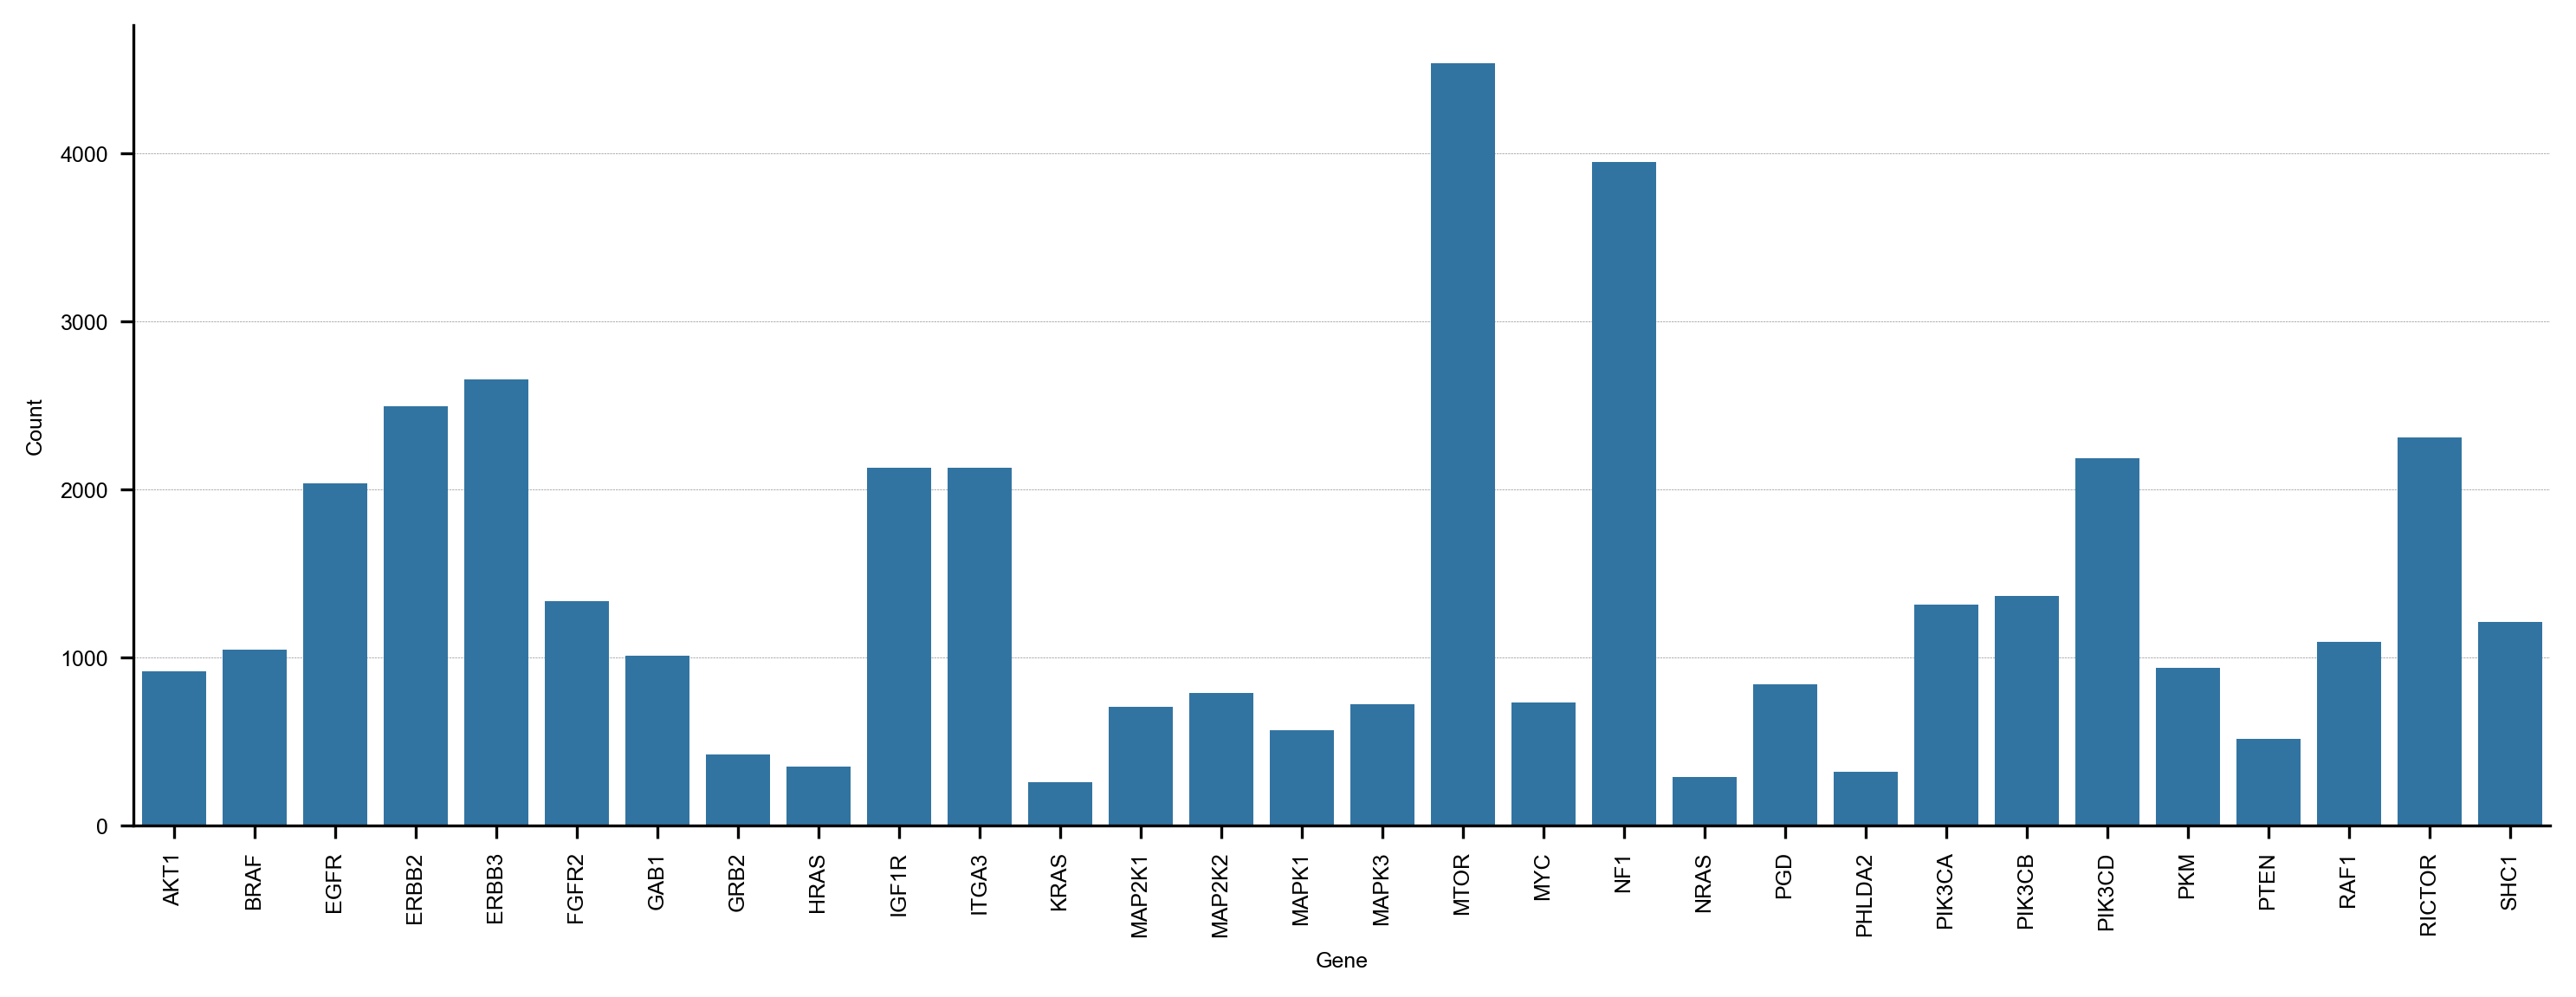

In [16]:
counts_before_DS = (
    annotated_variants_train
    .groupby(["Gene", "Class"])
    .size()
    .reset_index(name="Count")
)

counts_non_hits_before_DS = counts_before_DS[counts_before_DS["Class"] == "Neutral"]

plt.figure(figsize=(12,4))
sns.barplot(
    data=counts_non_hits_before_DS,
    x="Gene", y="Count", errorbar=None
)

plt.xticks(rotation=90)
plt.show()

In [15]:
def stratified_downsampling(df, class_col, random_state=None):
    #Infer majority class + target size (length of the second largest class)
    class_counts = df[class_col].value_counts()
    majority_class = class_counts.idxmax()
    target_size = class_counts.nlargest(2).iloc[-1]

    #Separate majority class and other classes
    major_df = df[df[class_col] == majority_class]
    other_df = df[df[class_col] != majority_class]

    # If majority already not bigger than target, nothing to do
    if len(major_df) <= target_size:
        return df.copy()
    
    #Compute distribution of the majority df across Cell_Line and Gene
    major_distribution = (
        major_df
        .groupby(['Cell_Line', 'Gene'])
        .size()
        .reset_index(name='Count')
    )

    # Calculate proportions
    major_distribution['Proportion'] = major_distribution['Count'] / major_distribution['Count'].sum()

    # Determine number of samples to select from each Cell_Line × Gene group
    major_distribution['Target'] = np.floor(major_distribution['Proportion'] * target_size).astype(int)

    # Adjust target to ensure total matches target size 
    # i.e., distribute the remaining samples to the groups with the largest fractional remainders
    difference = target_size - major_distribution['Target'].sum()
    if difference > 0:
        fractional_parts = major_distribution['Proportion'] * target_size - major_distribution['Target']
        top_idx = fractional_parts.nlargest(difference).index
        major_distribution.loc[top_idx, 'Target'] += 1

    #Perform stratified downsampling
    downsampled_major_dfs= []
    for _, row in major_distribution.iterrows():
        cell_line = row['Cell_Line']
        gene = row['Gene']
        target = row['Target']

        subset = major_df[(major_df['Cell_Line'] == cell_line) & (major_df['Gene'] == gene)]

        if target > 0:
            n_sampled = min(target, len(subset)) # in case it is a very small group - but can lead to less samples than target_size overall
            downsampled_major_dfs.append(subset.sample(n=n_sampled, random_state=random_state))
    
    #Keep the indices until after the Top up step
    downsampled_majority_class_df = pd.concat(downsampled_major_dfs, axis=0)

    #Top up if needed (if very small groups caused total to be less than target_size)
    current_size = len(downsampled_majority_class_df)
    missing = target_size - current_size

    if missing>0: #ask supervisor if this is really needed
        remaining_samples = major_df.loc[~major_df.index.isin(downsampled_majority_class_df.index)]
        assert not remaining_samples.empty, ("Logic error: remaining_samples is empty but target_size not reached.")
        extra_n= min(missing, len(remaining_samples))
        extra_samples = remaining_samples.sample(n=extra_n, random_state=random_state)

        #Random subsample from the remaining samples now
        downsampled_majority_class_df = pd.concat([downsampled_majority_class_df, extra_samples], axis=0)

    # Reset index only at the end
    downsampled_majority_class_df = downsampled_majority_class_df.reset_index(drop=True)

    #Combine downsampled majority class with other classes
    balanced_df = pd.concat([downsampled_majority_class_df, other_df], ignore_index=True)

    return balanced_df

In [18]:
#Balanced Dataset
annotated_variants_train_balanced = stratified_downsampling(annotated_variants_train, class_col='Class', random_state=1)

In [19]:
print("Final class counts:")
print(annotated_variants_train_balanced["Class"].value_counts())

Final class counts:
Class
Neutral        567
Resistance     567
Sensitivity    242
Name: count, dtype: int64


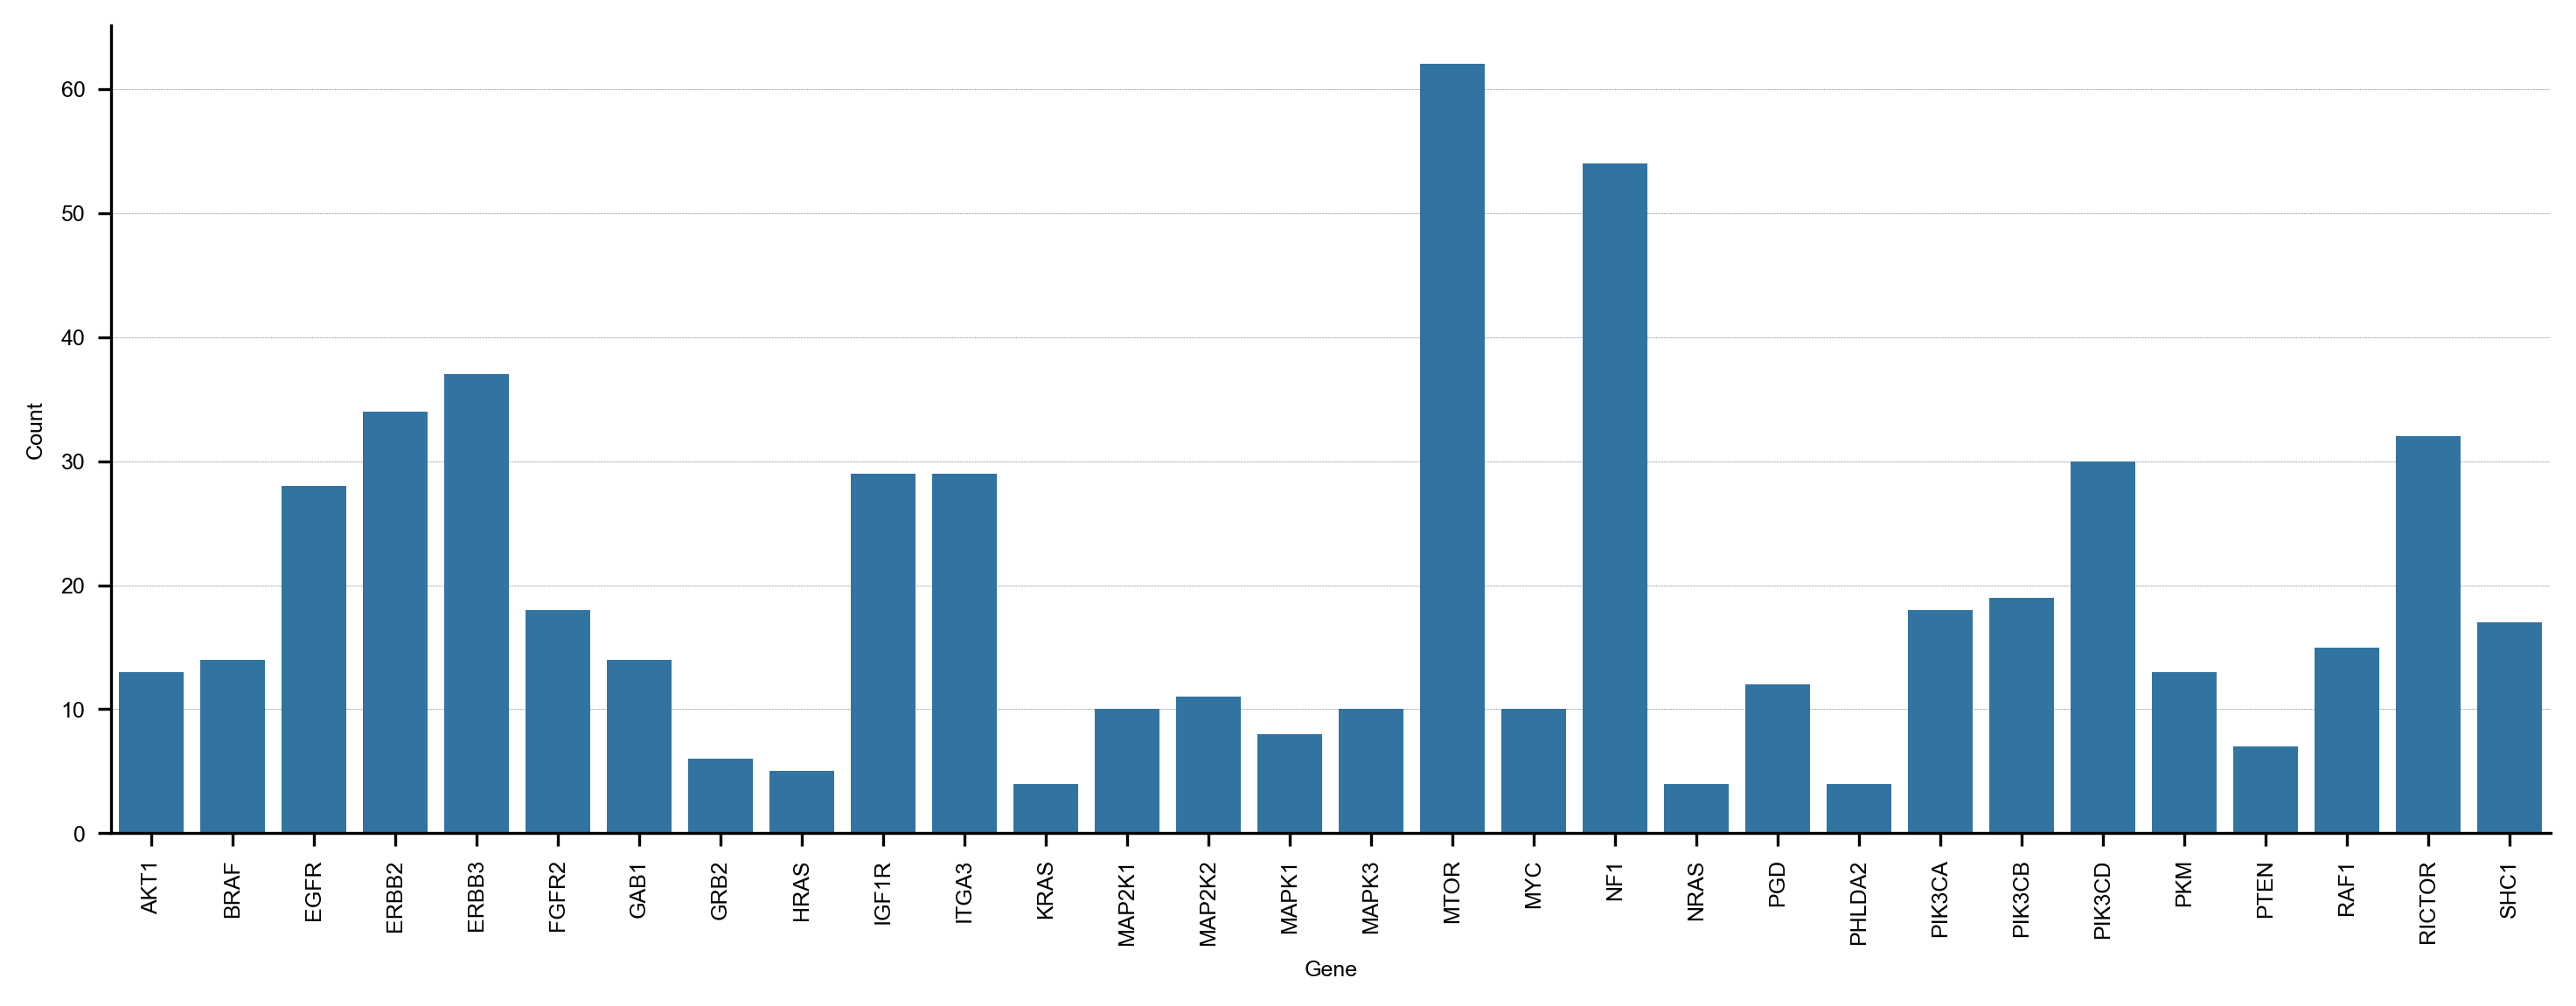

In [20]:
#Check distribution of non-hits after downsampling

counts_after_DS = (
    annotated_variants_train_balanced
    .groupby(["Gene", "Class"])
    .size()
    .reset_index(name="Count")
)

counts_non_hits_after_DS = counts_after_DS[counts_after_DS["Class"] == "Neutral"]

plt.figure(figsize=(12,4))
sns.barplot(
    data=counts_non_hits_after_DS,
    x="Gene", y="Count", errorbar=None
)

plt.xticks(rotation=90)
plt.show()

In [21]:
comparison_df = pd.DataFrame({
    'Before_Downsampling': annotated_variants_train['Class'].value_counts().sort_index(),
    'After_Downsampling': annotated_variants_train_balanced['Class'].value_counts().sort_index()
}).reset_index().rename(columns={'index': 'Class'})
comparison_df

,Class,Before_Downsampling,After_Downsampling
0,Neutral,41203,567
1,Resistance,567,567
2,Sensitivity,242,242


In [74]:
# Compute proportions within each group (Cell_Line × Gene)
prop_before = counts_non_hits_before_DS.copy()
prop_before["Proportion_before_DS"] = round(prop_before["Count"] / prop_before["Count"].sum(),4)
prop_before = prop_before[["Gene", "Proportion_before_DS"]]

prop_after = counts_non_hits_after_DS.copy()
prop_after["Proportion_after_DS"] = round(prop_after["Count"] / prop_after["Count"].sum(), 4)
prop_after = prop_after[["Gene", "Proportion_after_DS"]]


prop_compare = pd.merge(prop_before, prop_after,
                        on="Gene", how="inner")

# Correlation of proportions
corr = prop_compare["Proportion_before_DS"].corr(prop_compare["Proportion_after_DS"])

print("Correlation of per-group proportions (before vs after downsampling):", round(corr, 4))
print("\nProportion comparison (first 10 rows):")
print(prop_compare.head(10))

Correlation of per-group proportions (before vs after downsampling): 0.9988

Proportion comparison (first 10 rows):
    Gene  Proportion_before_DS  Proportion_after_DS
0   AKT1                0.0222               0.0226
1   BRAF                0.0254               0.0271
2   EGFR                0.0503               0.0498
3  ERBB2                0.0608               0.0588
4  ERBB3                0.0639               0.0633
5  FGFR2                0.0322               0.0317
6   GAB1                0.0246               0.0226
7   GRB2                0.0103               0.0090
8   HRAS                0.0085               0.0090
9  IGF1R                0.0549               0.0543


## Modeling

In [16]:
#Define meta data columns to drop
meta_cols=[
    'Guide', 'Editor', 'Gene', 'Cell_Line', 'Drug', 'zscore', 'Source', 'Target Transcript ID', 'uniprot_accession',
    'RefSeq match transcript (MANE Select)', 'Amino Acid Edits', 'aa_change', 'pocket_id', 'Class'
]

In [20]:
def train_test_once_no_cv(train_df, test_df, model, meta_cols, le, stratified_downsampling, class_col, random_state_for_downsampling):
    
    #Downsample training set
    train_df_balanced = stratified_downsampling(train_df, class_col = class_col, random_state=random_state_for_downsampling)
    test_df_balanced = stratified_downsampling(test_df, class_col = class_col, random_state=1)

    #Without downsampling for this version
    #train_df_balanced = train_df.copy()

    #Print class distribution after downsampling
    print("Class distribution after downsampling:")
    print(train_df_balanced['Class'].value_counts())

    #Print class distribution in test set after downsampling
    print("Test set class distribution after downsampling:")
    print(test_df_balanced['Class'].value_counts())

    #Split features and labels
    X_train = train_df_balanced.drop(columns="Class_encoded")
    y_train = train_df_balanced["Class_encoded"]

    X_test = test_df_balanced.drop(columns="Class_encoded")
    y_test = test_df_balanced["Class_encoded"]

    #Store meta data for test set
    meta_X_test = X_test[meta_cols].copy()
    meta_X_test['original_index'] = X_test.index

    X_train = X_train.drop(columns=meta_cols)
    X_test  = X_test.drop(columns=meta_cols)

    #Train model
    model.fit(X_train, y_train)

    #Predict on test set
    y_pred = model.predict(X_test)
    probs = model.predict_proba(X_test)

    #Metrics
    class_names = list(le.classes_)
    metrics = {}

    report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)

    metrics['accuracy'] = report['accuracy']

    for avg_key in ['macro avg', 'weighted avg']:
        metrics[f'precision_{avg_key}'] = report[avg_key]['precision']
        metrics[f'recall_{avg_key}'] = report[avg_key]['recall']
        metrics[f'f1_{avg_key}'] = report[avg_key]['f1-score']

    for cname in class_names:
        metrics[f'precision_{cname}'] = report[cname]['precision']
        metrics[f'recall_{cname}'] = report[cname]['recall']
        metrics[f'f1_{cname}'] = report[cname]['f1-score']

    
    n_classes = len(class_names)

    #ROC AUC
    if n_classes == 2:
        # Binary case
        metrics['roc_auc'] = roc_auc_score(y_test, probs[:, 1])
    else:
        # Multiclass 
        metrics['roc_auc_weighted'] = roc_auc_score(y_test, probs, multi_class='ovr', average='weighted')
        metrics['roc_auc_macro'] = roc_auc_score(y_test, probs, multi_class='ovr', average='macro')

    #PR AUC
    if n_classes == 2:
        # Binary case
        metrics['pr_auc'] = average_precision_score(y_test, probs[:, 1])
    else:
        # Multiclass 
        metrics['pr_auc_weighted'] = average_precision_score(y_test, probs, average='weighted')
        metrics['pr_auc_macro'] = average_precision_score(y_test, probs, average='macro')

    #Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(class_names)))

    return metrics, cm, y_test.values, y_pred, probs

In [33]:
#The guides in the test set are the same as used for training 

def train_test_once_no_cv_same_guides(train_df, test_df, model, meta_cols, le, stratified_downsampling, class_col, random_state_for_downsampling):
    
    #Downsample training set
    train_df_balanced = stratified_downsampling(train_df, class_col = class_col, random_state=random_state_for_downsampling)

    #Without downsampling for this version
    #train_df_balanced = train_df.copy()

    #Print class distribution after downsampling
    print("Class distribution after downsampling:")
    print(train_df_balanced['Class'].value_counts())

    #Filter test set for guides present in the training set
    train_guides = set(train_df_balanced['Guide'])
    test_df = test_df[test_df['Guide'].isin(train_guides)].copy()
    assert len(test_df) > 0, "Test set became empty after filtering"

    print("Number of guides in train:", len(train_guides))
    print("Number of test samples after filtering:", len(test_df))

    #Print new class distribution in test set after filtering
    print("Test set class distribution after filtering:")
    print(test_df['Class'].value_counts())

    #Downsample test
    test_df_balanced = stratified_downsampling(test_df, class_col = class_col, random_state=1)

    #Print class distribution in test set after downsampling
    print("Test set class distribution after downsampling:")
    print(test_df_balanced['Class'].value_counts())

    #Split features and labels
    X_train = train_df_balanced.drop(columns="Class_encoded")
    y_train = train_df_balanced["Class_encoded"]

    X_test = test_df_balanced.drop(columns="Class_encoded")
    y_test = test_df_balanced["Class_encoded"]

    #Store meta data for test set
    meta_X_test = X_test[meta_cols].copy()
    meta_X_test['original_index'] = X_test.index

    X_train = X_train.drop(columns=meta_cols)
    X_test  = X_test.drop(columns=meta_cols)

    #Train model
    model.fit(X_train, y_train)

    #Predict on test set
    y_pred = model.predict(X_test)
    probs = model.predict_proba(X_test)

    #Metrics
    class_names = list(le.classes_)
    metrics = {}

    report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)

    metrics['accuracy'] = report['accuracy']

    for avg_key in ['macro avg', 'weighted avg']:
        metrics[f'precision_{avg_key}'] = report[avg_key]['precision']
        metrics[f'recall_{avg_key}'] = report[avg_key]['recall']
        metrics[f'f1_{avg_key}'] = report[avg_key]['f1-score']

    for cname in class_names:
        metrics[f'precision_{cname}'] = report[cname]['precision']
        metrics[f'recall_{cname}'] = report[cname]['recall']
        metrics[f'f1_{cname}'] = report[cname]['f1-score']

    #ROC AUC
    metrics['roc_auc_weighted'] = roc_auc_score(y_test, probs, multi_class='ovr', average='weighted')
    metrics['roc_auc_macro'] = roc_auc_score(y_test, probs, multi_class='ovr', average='macro')

    #PR AUC
    metrics['pr_auc_weighted'] = average_precision_score(y_test, probs, average='weighted')
    metrics['pr_auc_macro'] = average_precision_score(y_test, probs, average='macro')

    #Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(class_names)))

    return metrics, cm, y_test.values, y_pred, probs

### Define Model and Cross-Validation

In [18]:
optimized_params = {'n_estimators': 473,
                    'max_depth': 8,
                    'learning_rate': 0.014757846958987166,
                    'subsample': 0.9074779169306355,
                    'colsample_bytree': 0.5480484893807359,
                    'min_child_weight': 1,
                    'reg_alpha': 0.0004937375718649116,
                    'reg_lambda': 0.000319094062330884,
                    'gamma': 0.6244886434704836}


#Define optimized XGBClassifier with Optuna parameters  
xgb_classifier_optimized = XGBClassifier(
    **optimized_params                   
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Run Model

In [44]:
# Run multiple times to get average performance across different downsamplings
n_runs=10

all_metrics, all_cms = [], []
all_y_true_runs, all_y_pred_runs, all_probs_runs = [], [], []

for i in range(n_runs):
    print(f"\n--- Run {i+1}/{n_runs} ---")

    metrics, cm, y_true, y_pred, probs = train_test_once_no_cv_same_guides(
        train_df=annotated_variants_train,
        test_df=annotated_variants_test,
        model=xgb_classifier_optimized,
        meta_cols=meta_cols,
        le=le,
        stratified_downsampling=stratified_downsampling,
        class_col="Class",
        random_state_for_downsampling=i
    )

    all_metrics.append(metrics)
    all_cms.append(cm)
    all_y_true_runs.append(y_true)
    all_y_pred_runs.append(y_pred)
    all_probs_runs.append(probs)

    print("Metrics:", metrics)
    print("Confusion Matrix:\n", cm)

# === Aggregate metrics across runs ===
metrics_df = pd.DataFrame(all_metrics)
metrics_mean = metrics_df.mean()
metrics_std = metrics_df.std()

cm_mean = np.mean(np.array(all_cms, dtype=float), axis=0)
cm_std  = np.std(np.array(all_cms, dtype=float), axis=0)

desired_order = ["Sensitivity", "Neutral", "Resistance"]

# Map to label encoder indices
reorder_idx = [list(le.classes_).index(c) for c in desired_order]

# Reorder rows and columns
cm_mean = cm_mean[np.ix_(reorder_idx, reorder_idx)]
cm_std  = cm_std[np.ix_(reorder_idx, reorder_idx)]

# Update class_names for correct axis labels
class_names_reordered = desired_order

print("=== Mean metrics ===")
print(metrics_mean)
print("\n=== Std metrics ===")
print(metrics_std)

print("\n=== Mean confusion matrix ===")
print(cm_mean)
print("\n=== Std confusion matrix ===")
print(cm_std)


--- Run 1/10 ---
Class distribution after downsampling:
Class
Neutral        221
Resistance     221
Sensitivity    209
Name: count, dtype: int64
Number of guides in train: 591
Number of test samples after filtering: 1773
Test set class distribution after filtering:
Class
Neutral        1597
Resistance      141
Sensitivity      35
Name: count, dtype: int64
Test set class distribution after downsampling:
Class
Neutral        141
Resistance     141
Sensitivity     35
Name: count, dtype: int64
Metrics: {'accuracy': 0.6719242902208202, 'precision_macro avg': 0.5756425333196986, 'recall_macro avg': 0.5536643026004728, 'f1_macro avg': 0.557671953636688, 'precision_weighted avg': 0.6617334980030277, 'recall_weighted avg': 0.6719242902208202, 'f1_weighted avg': 0.6620193964322422, 'precision_Neutral': 0.6607142857142857, 'recall_Neutral': 0.7872340425531915, 'f1_Neutral': 0.7184466019417476, 'precision_Resistance': 0.7480314960629921, 'recall_Resistance': 0.6737588652482269, 'f1_Resistance': 0

In [45]:
def summarize_results(metrics_list, cms, class_names):
    """
    Summarize metrics (global + class-wise) and confusion matrices across runs.

    Parameters
    ----------
    metrics_list : list of dict
        Each element is the metrics dict returned from train_test_once.
    cms : list of np.ndarray
        Confusion matrices (one per run).
    class_names : list
        Names of classes for the confusion matrix.
    """

    # === Metrics summary ===
    metrics_keys = metrics_list[0].keys()
    summary = {}
    for key in metrics_keys:
        values = np.array([m[key] for m in metrics_list])
        summary[key] = (np.mean(values), np.std(values))

    print("\n=== Metrics Summary (mean ± std) ===")

    # Global averages
    for k in ["accuracy", "roc_auc_weighted", "roc_auc_macro",
              "pr_auc_weighted", "pr_auc_macro"]:
        mean, std = summary[k]
        print(f"{k:20s}: {mean:.3f} ± {std:.3f}")

    # Macro/weighted averages
    for k in ["precision_macro avg", "recall_macro avg", "f1_macro avg",
              "precision_weighted avg", "recall_weighted avg", "f1_weighted avg"]:
        if k in summary:
            mean, std = summary[k]
            print(f"{k:20s}: {mean:.3f} ± {std:.3f}")

    # Class-wise metrics
    print("\n=== Class-wise Metrics (mean ± std) ===")
    for cname in class_names:
        for metric in ["precision", "recall", "f1"]:
            key = f"{metric}_{cname}"
            if key in summary:
                mean, std = summary[key]
                print(f"{cname:10s} {metric:10s}: {mean:.3f} ± {std:.3f}")

   # === Confusion Matrix summary ===
    cm_array = np.stack(cms)
    cm_mean = np.mean(cm_array, axis=0)
    cm_std = np.std(cm_array, axis=0)

    # === Reorder ===
    desired_order = ["Sensitivity", "Neutral", "Resistance"]
    reorder_idx = [list(class_names).index(c) for c in desired_order]

    cm_mean = cm_mean[np.ix_(reorder_idx, reorder_idx)]
    cm_std  = cm_std[np.ix_(reorder_idx, reorder_idx)]

    class_names = desired_order

    # Combined annotated version
    combined = np.empty(cm_mean.shape, dtype=object)
    for i in range(cm_mean.shape[0]):
        for j in range(cm_mean.shape[1]):
            mean_val = int(round(cm_mean[i, j]))   
            std_val = int(cm_std[i, j])       
            combined[i, j] = f"{mean_val}±{std_val}"


    plt.figure(figsize=(2.5, 2.5))
    sns.heatmap(cm_mean, annot=combined, fmt="", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 7})
    #plt.title("Confusion Matrix (mean ± std)")
    plt.yticks(fontsize=8)
    plt.xticks(fontsize=8)
    plt.xlabel("Predicted Label", fontsize=9)
    plt.ylabel("True Label", fontsize=9)
    plt.show()

# === Bar plot: Precision & Recall per class (mean ± std) ===
    precision_means = [summary[f"precision_{c}"][0] for c in class_names]
    precision_stds  = [summary[f"precision_{c}"][1] for c in class_names]
    recall_means    = [summary[f"recall_{c}"][0] for c in class_names]
    recall_stds     = [summary[f"recall_{c}"][1] for c in class_names]

    x = np.arange(len(class_names))
    width = 0.35

    plt.figure(figsize=(6, 5))
    bars1 = plt.bar(x - width/2, precision_means, width,
                    yerr=precision_stds, capsize=3,
                    label="Precision", color="lightsteelblue")
    bars2 = plt.bar(x + width/2, recall_means, width,
                    yerr=recall_stds, capsize=3,
                    label="Recall", color="midnightblue")

    # Add numbers on top
    for bar in bars1:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2 + 0.105, height + 0.005,
                 f"{height:.2f}", ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2 + 0.105, height + 0.005,
                 f"{height:.2f}", ha='center', va='bottom', fontsize=8)

    plt.xticks(x, class_names, fontsize=8)
    plt.ylabel("Score", fontsize=9)
    plt.ylim(0, 1.05)
    plt.legend(loc="upper right", fontsize=6)
    plt.show()

    return summary, cm_mean, cm_std


=== Metrics Summary (mean ± std) ===
accuracy            : 0.642 ± 0.025
roc_auc_weighted    : 0.771 ± 0.013
roc_auc_macro       : 0.734 ± 0.013
pr_auc_weighted     : 0.691 ± 0.018
pr_auc_macro        : 0.564 ± 0.013
precision_macro avg : 0.544 ± 0.019
recall_macro avg    : 0.529 ± 0.020
f1_macro avg        : 0.530 ± 0.022
precision_weighted avg: 0.635 ± 0.019
recall_weighted avg : 0.642 ± 0.025
f1_weighted avg     : 0.633 ± 0.025

=== Class-wise Metrics (mean ± std) ===
Neutral    precision : 0.639 ± 0.033
Neutral    recall    : 0.758 ± 0.028
Neutral    f1        : 0.692 ± 0.020
Resistance precision : 0.722 ± 0.019
Resistance recall    : 0.637 ± 0.065
Resistance f1        : 0.675 ± 0.039
Sensitivity precision : 0.273 ± 0.029
Sensitivity recall    : 0.191 ± 0.035
Sensitivity f1        : 0.224 ± 0.032


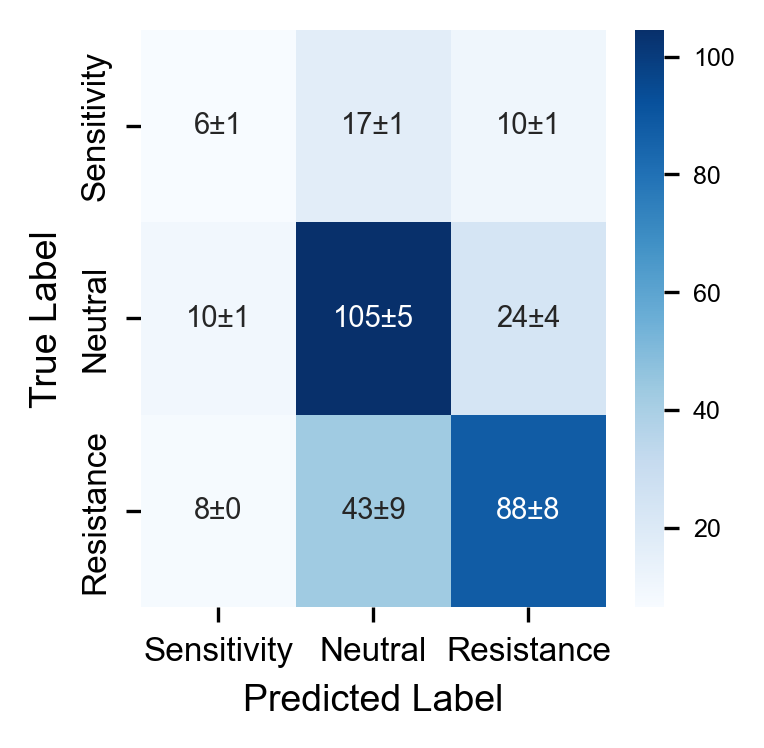

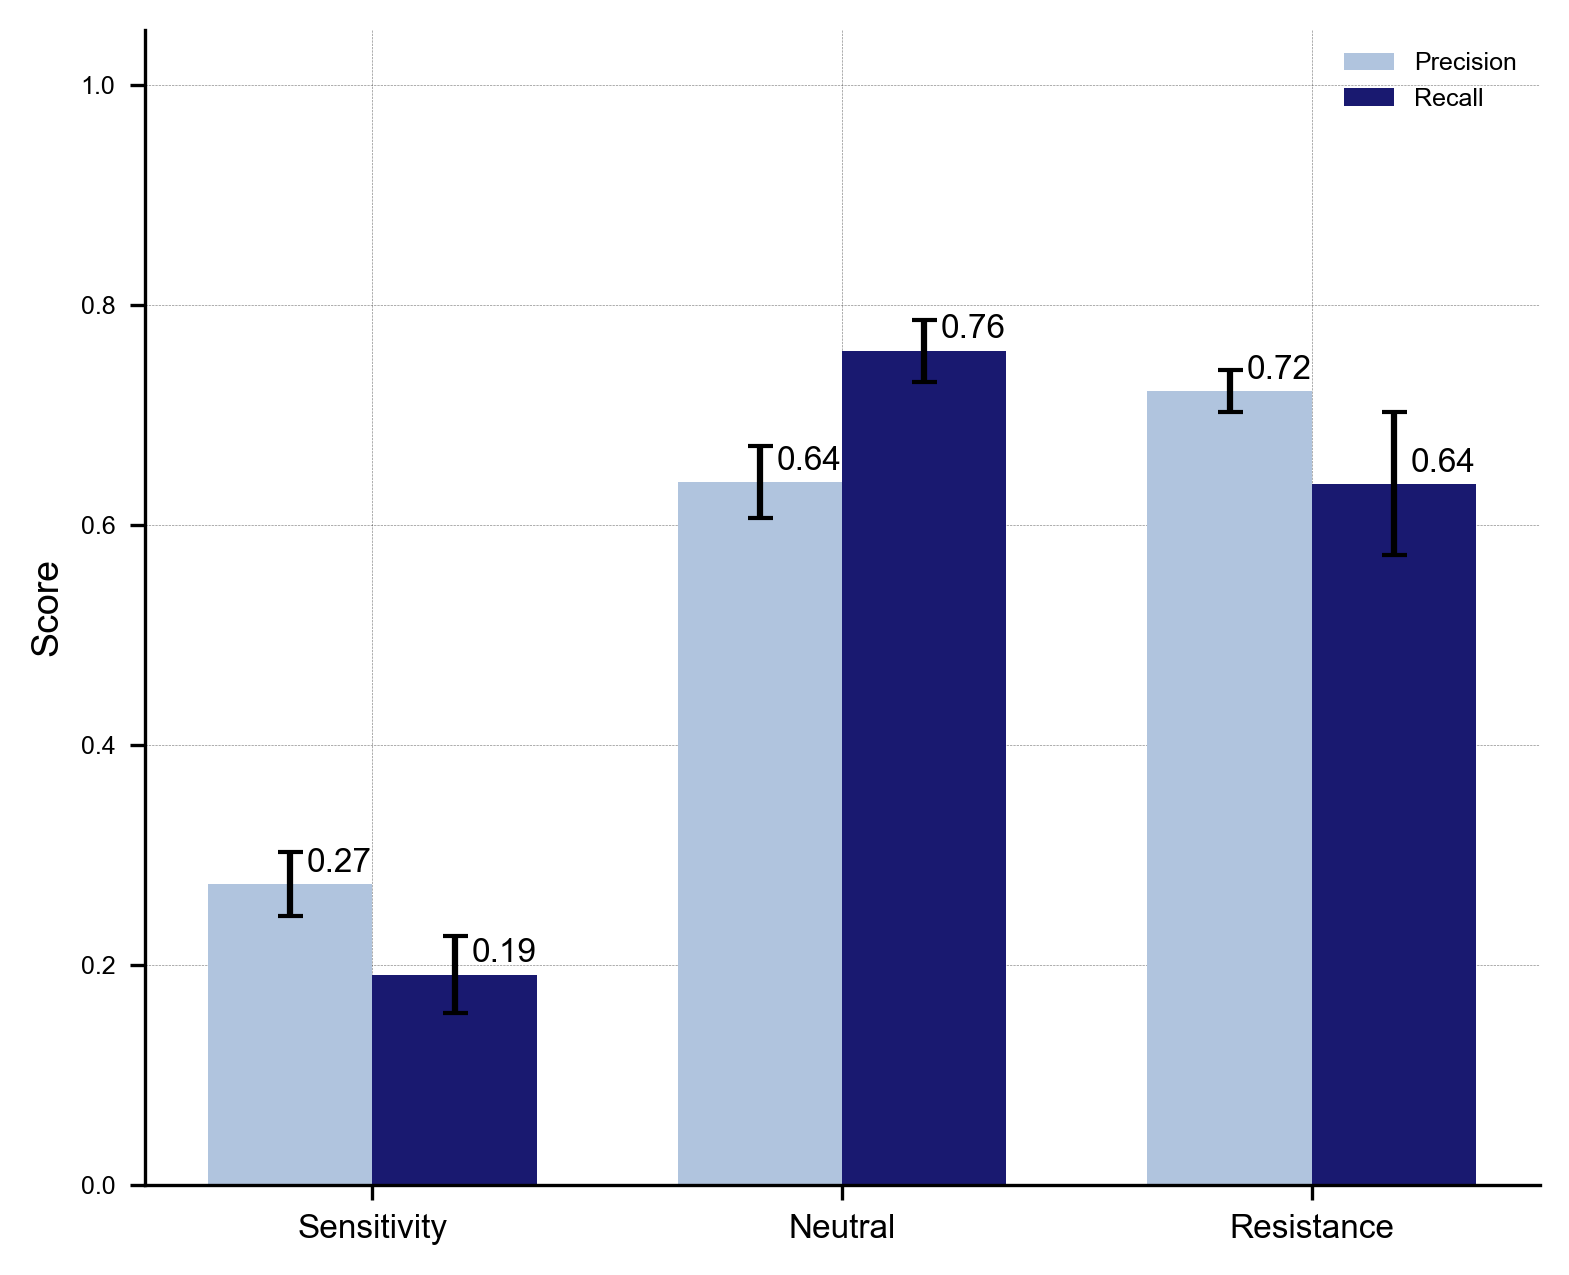

In [46]:
metrics_summary, cm_mean, cm_std = summarize_results(all_metrics, all_cms,
                                                     class_names=le.classes_)

### F1 plot per class

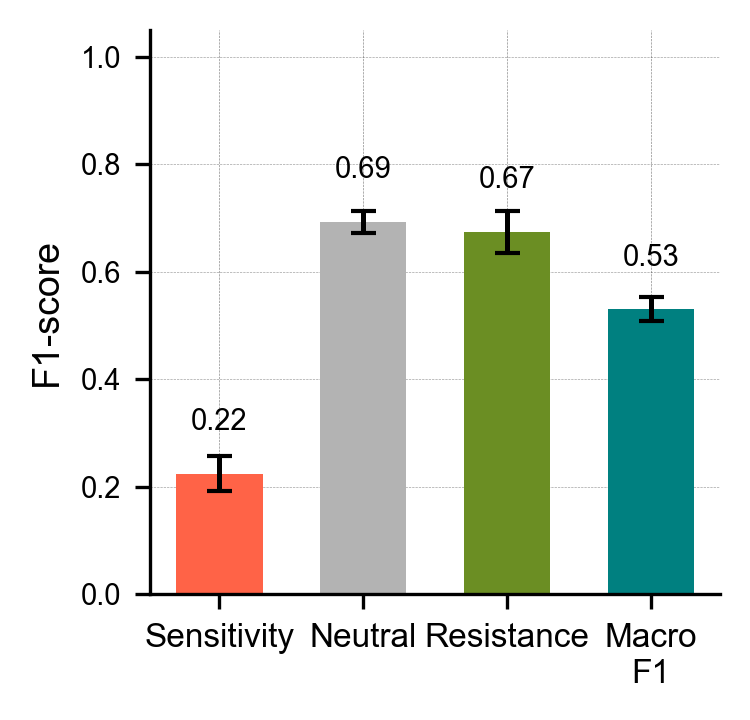

In [47]:
# Define your desired class order (using the metric keys used to index all metrics )
class_order = ["Sensitivity", "Neutral", "Resistance",  'macro avg']

# Display labels for the x-axis
display_labels = ["Sensitivity", "Neutral", "Resistance",  "Macro\nF1"]

# Compute mean and std in that order
f1_means = [np.mean([m[f"f1_{c}"] for m in all_metrics]) for c in class_order]
f1_stds  = [np.std([m[f"f1_{c}"] for m in all_metrics]) for c in class_order]

# Define consistent colors for each class
colors_bar = ["tomato", "#b3b3b3", "olivedrab", 'teal']

x = np.arange(len(display_labels))
plt.figure(figsize=(2.6,2.5))

bars = plt.bar(x, f1_means, yerr=f1_stds, capsize=3, color=colors_bar, width = 0.6, error_kw=dict(ecolor='black', lw=1.2))

# Add value labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.07, f"{height:.2f}", ha='center', va='bottom', fontsize=7)

plt.xticks(x, display_labels, fontsize=8)
plt.ylabel("F1-score", fontsize=9)
plt.yticks(fontsize=7)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [180]:
#Save the dataset used for the F1 plot
f1_results_to_plot_df = pd.DataFrame({
    "Class": class_order,
    "F1_mean": f1_means,
    "F1_std": f1_stds
})

f1_results_to_plot_df.to_csv("/Users/carolinapinto/desktop/Tese/Plots/Benchmarking/f1_scores_across_10_runs_plot_benchmark2.1_train-ht29.csv", index=False)

### PR Curve

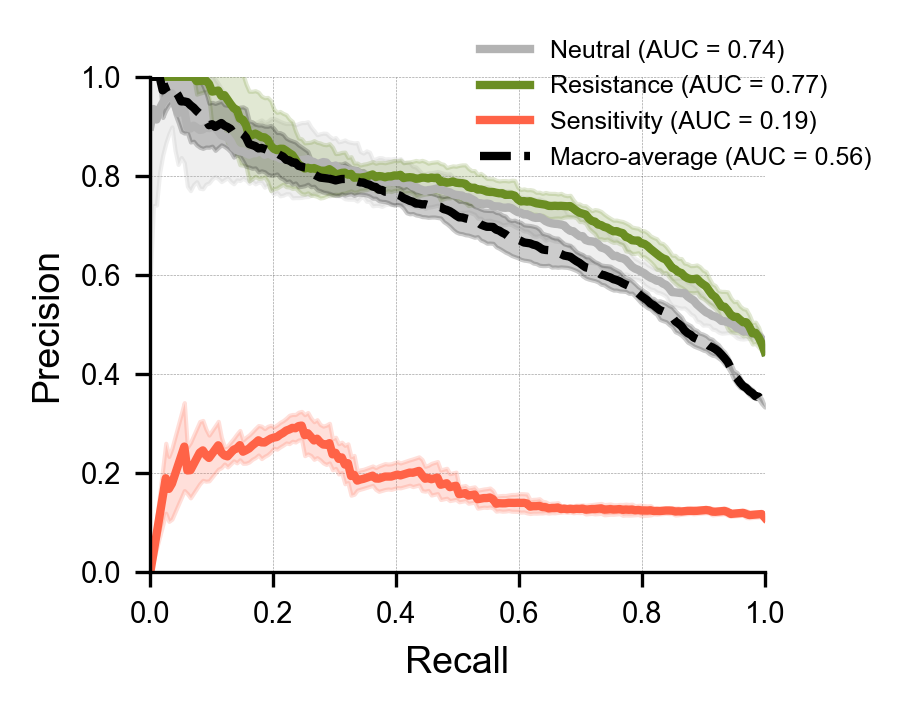

In [48]:
classes_for_binarize = np.arange(len(le.classes_))
colors = ["#b3b3b3", "olivedrab", "tomato"]
recall_grid = np.linspace(0, 1, 200)

plt.figure(figsize=(3,2.5))

for i, class_name in enumerate(le.classes_):
    precisions_interp = []
    aucs = []
    for y_true, probs in zip(all_y_true_runs, all_probs_runs):
        y_true_bin = label_binarize(y_true, classes=classes_for_binarize)
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], probs[:, i])
        auc = average_precision_score(y_true_bin[:, i], probs[:, i])
        aucs.append(auc)
        precisions_interp.append(np.interp(recall_grid, recall[::-1], precision[::-1]))

    mean_precision = np.mean(precisions_interp, axis=0)
    std_precision  = np.std(precisions_interp, axis=0)
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    plt.plot(recall_grid, mean_precision, color=colors[i], lw=2, label=f"{class_name} (AUC = {mean_auc:.2f})")
    plt.fill_between(recall_grid, mean_precision - std_precision, mean_precision + std_precision,
                     color=colors[i], alpha=0.2)

# Macro-average
macro_precisions = []
macro_aucs = []
for y_true, probs in zip(all_y_true_runs, all_probs_runs):
    y_true_bin = label_binarize(y_true, classes=classes_for_binarize)
    precision, recall, _ = precision_recall_curve(y_true_bin.ravel(), probs.ravel())
    macro_precisions.append(np.interp(recall_grid, recall[::-1], precision[::-1]))
    macro_aucs.append(average_precision_score(y_true_bin, probs, average="macro"))


mean_macro = np.mean(macro_precisions, axis=0)
std_macro = np.std(macro_precisions, axis=0)
mean_auc_macro = np.mean(macro_aucs)
std_auc_macro = np.std(macro_aucs)


plt.plot(recall_grid, mean_macro, color='black', lw=2, linestyle='--', label=f"Macro-average (AUC = {mean_auc_macro:.2f})")
plt.fill_between(recall_grid, mean_macro - std_macro, mean_macro + std_macro, color='black', alpha=0.2)

plt.xlabel("Recall", fontsize=9)
plt.xticks(fontsize=7)
plt.ylabel("Precision", fontsize=9)
plt.yticks(fontsize=7)
plt.legend(fontsize=6, loc="upper left", frameon=False, bbox_to_anchor=(0.5, 1.12))
#plt.legend(fontsize=7, loc="lower left", frameon=False, bbox_to_anchor=(0.13, 0.08))
plt.grid(alpha=0.4)
plt.ylim(0, 1)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [187]:
#Save PR curve data for reproducibility
classes_for_binarize = np.arange(len(le.classes_))
colors = ["#b3b3b3", "olivedrab", "tomato"]
recall_grid = np.linspace(0, 1, 200)

#Store all PR curves data 
all_pr_dfs = []
for i, class_name in enumerate(le.classes_):
    precisions_interp = []
    aucs = []
    for y_true, probs in zip(all_y_true_runs, all_probs_runs):
        y_true_bin = label_binarize(y_true, classes=classes_for_binarize)
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], probs[:, i])
        auc = average_precision_score(y_true_bin[:, i], probs[:, i])
        aucs.append(auc)
        precisions_interp.append(np.interp(recall_grid, recall[::-1], precision[::-1]))

    mean_precision = np.mean(precisions_interp, axis=0)
    std_precision  = np.std(precisions_interp, axis=0)
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    #Dataframe with the per-class PR curve data for reproducibility
    df_class = pd.DataFrame({
        "Recall": recall_grid,
        "Mean_Precision": mean_precision,
        "Std_Precision": std_precision,
        "Class": class_name,
        "Mean_AUC": mean_auc,
        "Std_AUC": std_auc
    })
    all_pr_dfs.append(df_class)

# Macro-average
macro_precisions = []
macro_aucs = []
for y_true, probs in zip(all_y_true_runs, all_probs_runs):
    y_true_bin = label_binarize(y_true, classes=classes_for_binarize)
    precision, recall, _ = precision_recall_curve(y_true_bin.ravel(), probs.ravel())
    macro_precisions.append(np.interp(recall_grid, recall[::-1], precision[::-1]))
    macro_aucs.append(average_precision_score(y_true_bin, probs, average="macro"))


mean_macro = np.mean(macro_precisions, axis=0)
std_macro = np.std(macro_precisions, axis=0)
mean_auc_macro = np.mean(macro_aucs)
std_auc_macro = np.std(macro_aucs)

df_macro = pd.DataFrame({
    "Recall": recall_grid,
    "Mean_Precision": mean_macro,
    "Std_Precision": std_macro,
    "Class": "Macro-average",
    "Mean_AUC": mean_auc_macro,
    "Std_AUC": std_auc_macro
})
all_pr_dfs.append(df_macro)

#Combine all into a single dataframe
pr_curve_data_df = pd.concat(all_pr_dfs, ignore_index=True)
pr_curve_data_df.to_csv("/Users/carolinapinto/desktop/Tese/Plots/Benchmarking/pr_curve_data_across_10_runs_plot_benchmark2.1_trainht29.csv", index=False)

## SHAP

Train the model once on the entire dataset and compute SHAP

In [34]:
#Prepare X and y
X= annotated_variants_train_balanced.drop(columns=meta_cols + ["Class_encoded"])
y= annotated_variants_train_balanced["Class_encoded"]
meta_data = annotated_variants_train_balanced[meta_cols]

#Train final model on the entire balanced dataset
final_model = XGBClassifier(**optimized_params)
final_model.fit(X, y)

#Predict y (for shap UMAP with predicted class)
X_test = annotated_variants_test.drop(columns=meta_cols + ["Class_encoded"])
y_true = annotated_variants_test["Class_encoded"]
y_pred_final = final_model.predict(X_test)

#Compute SHAP values on the training data (since we don't have a separate test set)
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

In [35]:
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(42012, 68, 3)


In [36]:
def get_stacked_shap_for_class(shap_values, X, le, target_class):
    
    class_idx = list(le.classes_).index(target_class)
    shap_c = shap_values[:, :, class_idx]

    assert shap_c.shape[0] == X.shape[0], "Row mismatch after stacking"
    return shap_c, X

def top_k_features_by_mean_abs_shap(shap_c, X, k=10):
    mean_abs = np.mean(np.abs(shap_c), axis=0)
    s = pd.Series(mean_abs, index=X.columns).sort_values(ascending=False)
    return s.head(k)  #Series: index=feature, value=mean|SHAP|


def plot_topk_shap_for_class(all_shap_values_runs, all_X_val_runs, le, target_class, k=10):
    shap_c, X = get_stacked_shap_for_class(all_shap_values_runs, all_X_val_runs, le, target_class)

    topk = top_k_features_by_mean_abs_shap(shap_c, X, k=k)
    top_features = topk.index.tolist()

    # Subset to top-k features
    cols_idx = [X.columns.get_loc(f) for f in top_features]
    shap_top = shap_c[:, cols_idx]
    X_top = X[top_features]

    print(f"\n=== {target_class}: Top {k} by mean(|SHAP|) ===")
    print(topk)

    # Bar: mean absolute SHAP
    shap.summary_plot(shap_top, X_top, plot_type="bar", max_display=k)

    # Beeswarm: distribution + direction
    shap.summary_plot(shap_top, X_top, max_display=k)

In [80]:
def get_stacked_shap_for_class(all_shap_values_runs, all_X_val_runs, le, target_class):
    """
    Stack SHAP values and corresponding feature matrices across
    all CV folds and runs for a given class.
    """
    # Get class index
    class_idx = list(le.classes_).index(target_class)

    shap_blocks = []
    X_blocks = []

    for fold_shap, X_val in zip(all_shap_values_runs, all_X_val_runs):
        # fold_shap shape: (n_samples, n_features, n_classes)
        shap_blocks.append(fold_shap[:, :, class_idx])
        X_blocks.append(X_val)

    shap_c = np.vstack(shap_blocks)
    X_c = pd.concat(X_blocks, axis=0)

    assert shap_c.shape[0] == X_c.shape[0], "Row mismatch after stacking"

    return shap_c, X_c


def top_k_features_by_mean_abs_shap(shap_c, X_c, k=10):
    mean_abs = np.mean(np.abs(shap_c), axis=0)
    s = pd.Series(mean_abs, index=X_c.columns).sort_values(ascending=False)
    return s.head(k)  # returns a Series: index=feature, value=mean|SHAP|


def plot_topk_shap_for_class(all_shap_values_runs, all_X_val_runs, le, target_class, k=10):
    shap_c, X_c = get_stacked_shap_for_class(all_shap_values_runs, all_X_val_runs, le, target_class)

    topk = top_k_features_by_mean_abs_shap(shap_c, X_c, k=k)
    top_features = topk.index.tolist()

    # Subset to top-k features
    cols_idx = [X_c.columns.get_loc(f) for f in top_features]
    shap_top = shap_c[:, cols_idx]
    X_top = X_c[top_features]

    print(f"\n=== {target_class}: Top {k} by mean(|SHAP|) ===")
    print(topk)

    # Bar: mean absolute SHAP
    shap.summary_plot(shap_top, X_top, plot_type="bar", max_display=k)

    # Beeswarm: distribution + direction
    shap.summary_plot(shap_top, X_top, max_display=k)



=== Sensitivity: Top 10 by mean(|SHAP|) ===
lnIC50                          0.306924
CRISPR_essentiality_score       0.195095
Gene_expression_voom            0.190443
protein_abundance_zscore        0.138148
CADD_PHRED                      0.099905
LOEUF                           0.086515
MPC_score                       0.045356
pocket_score_combined_scaled    0.044690
drug_target_gene_distance       0.042784
TSL                             0.038364
dtype: float32


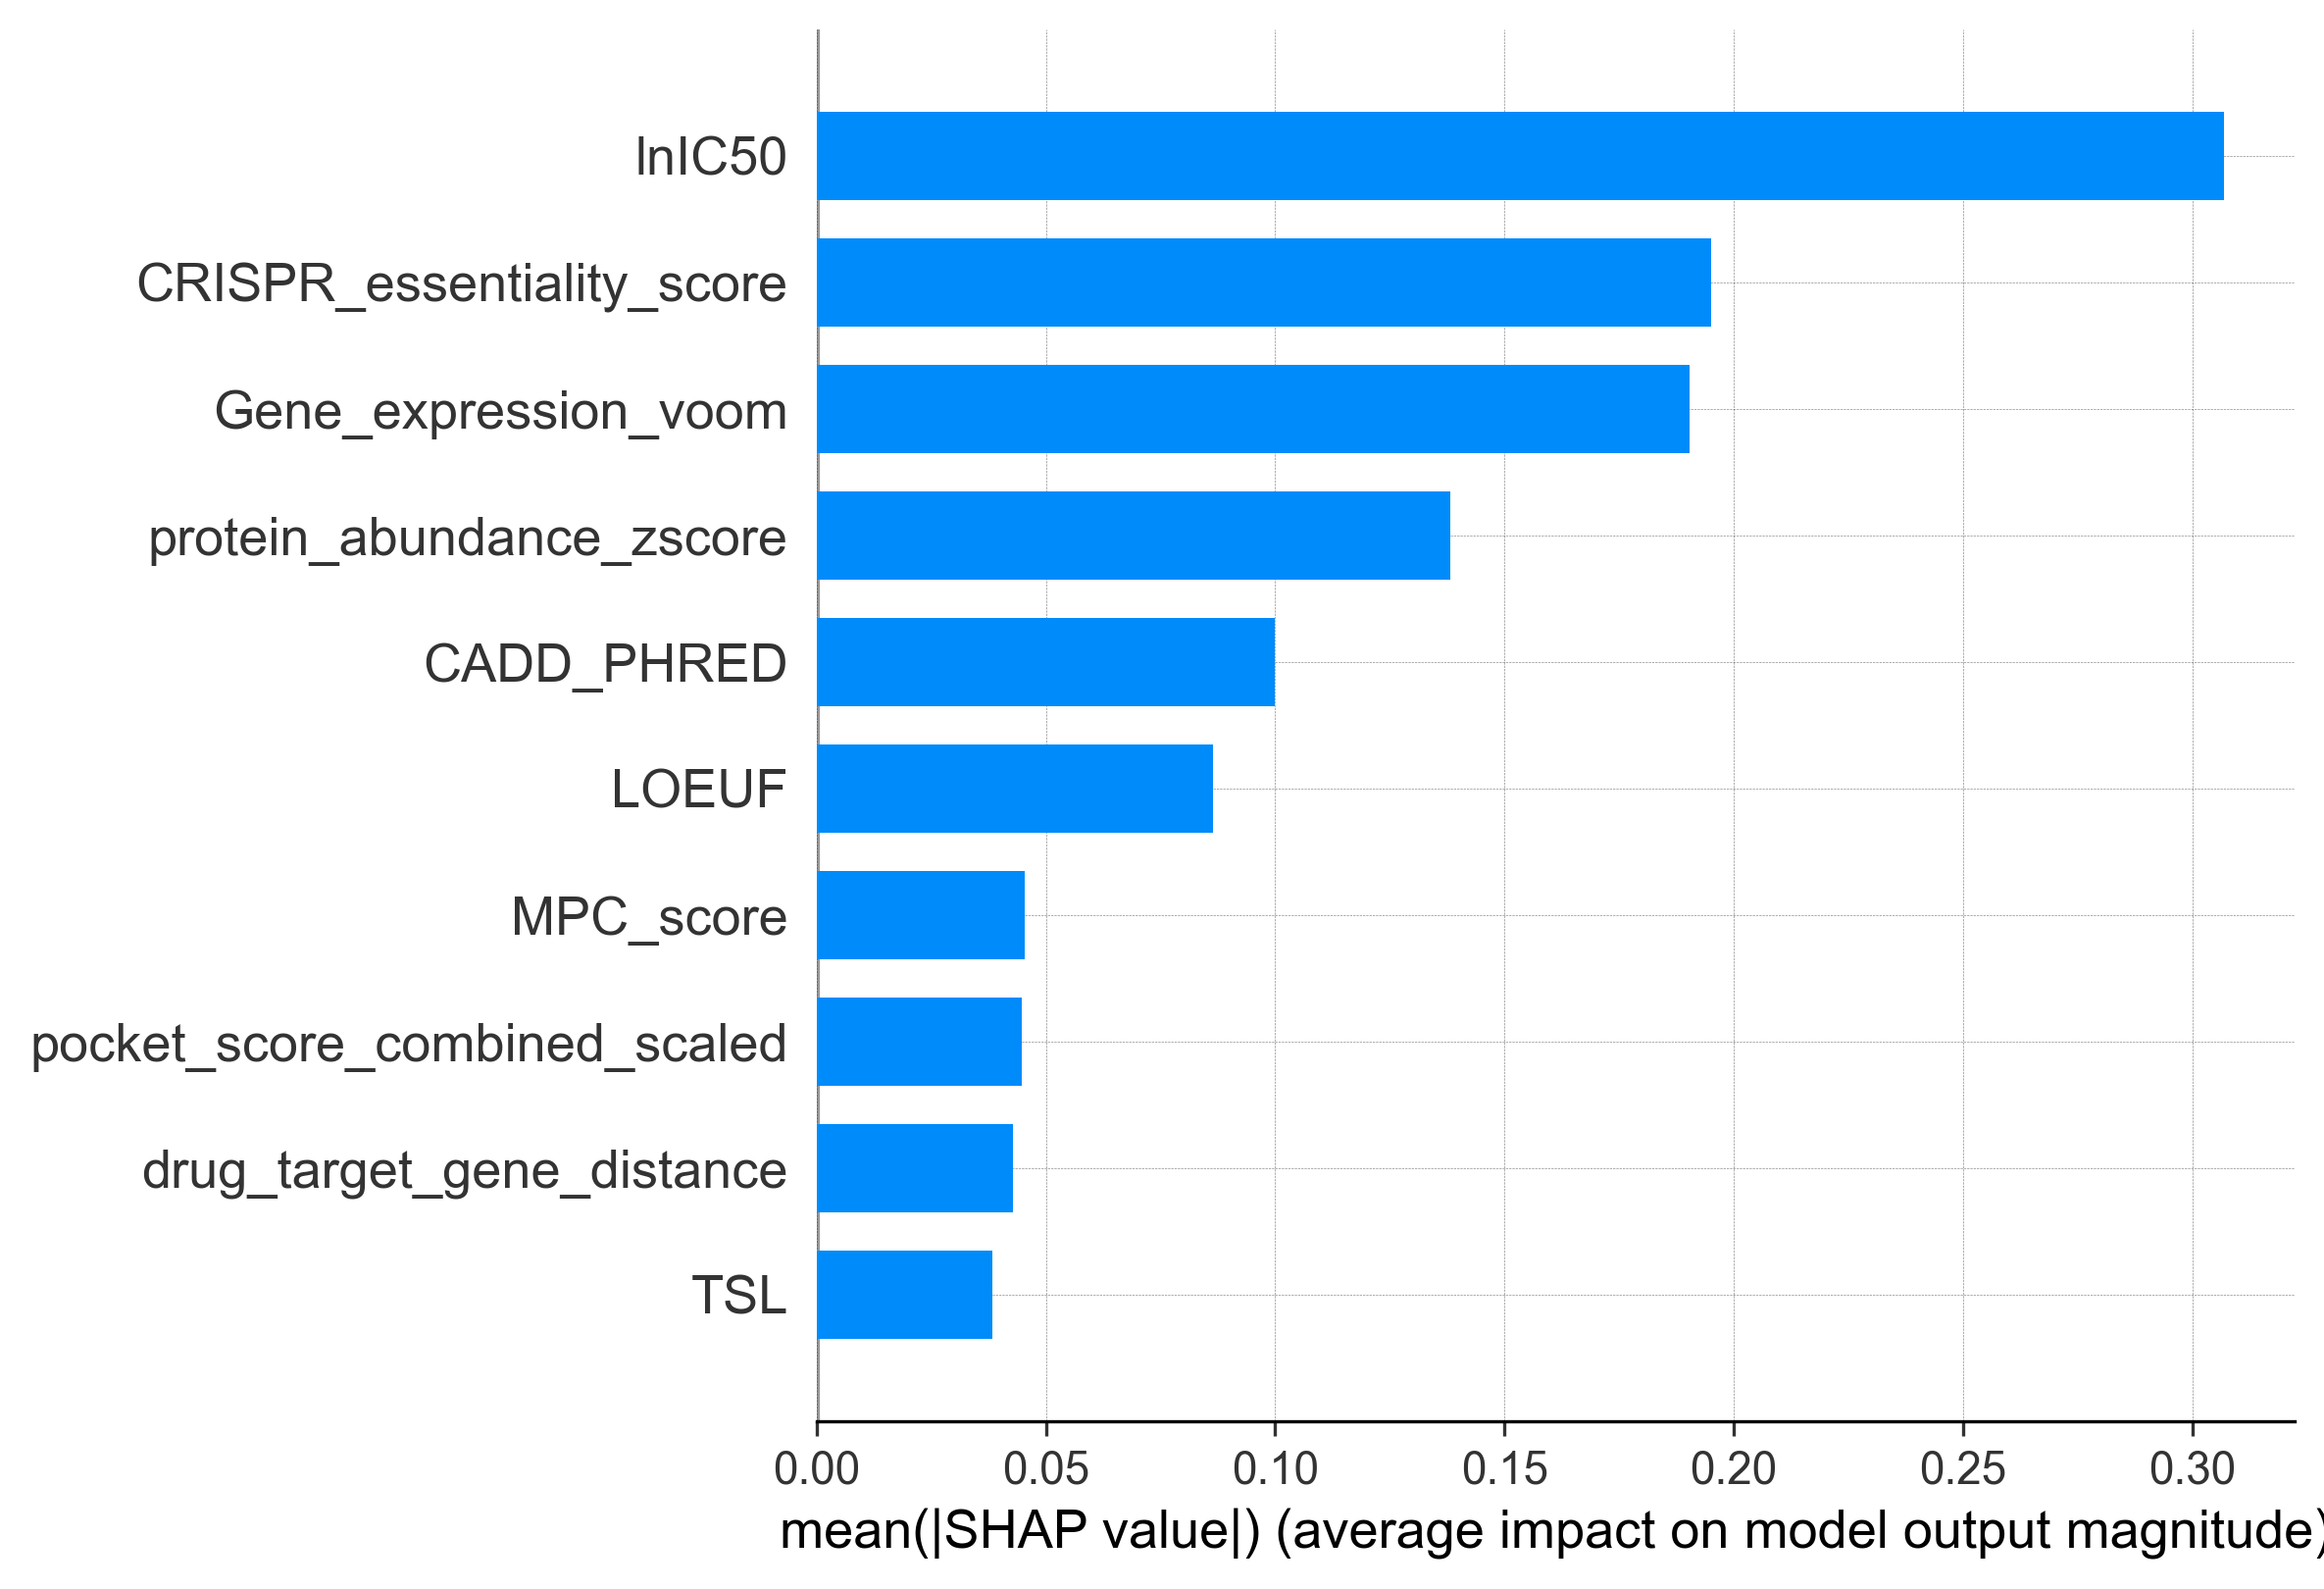

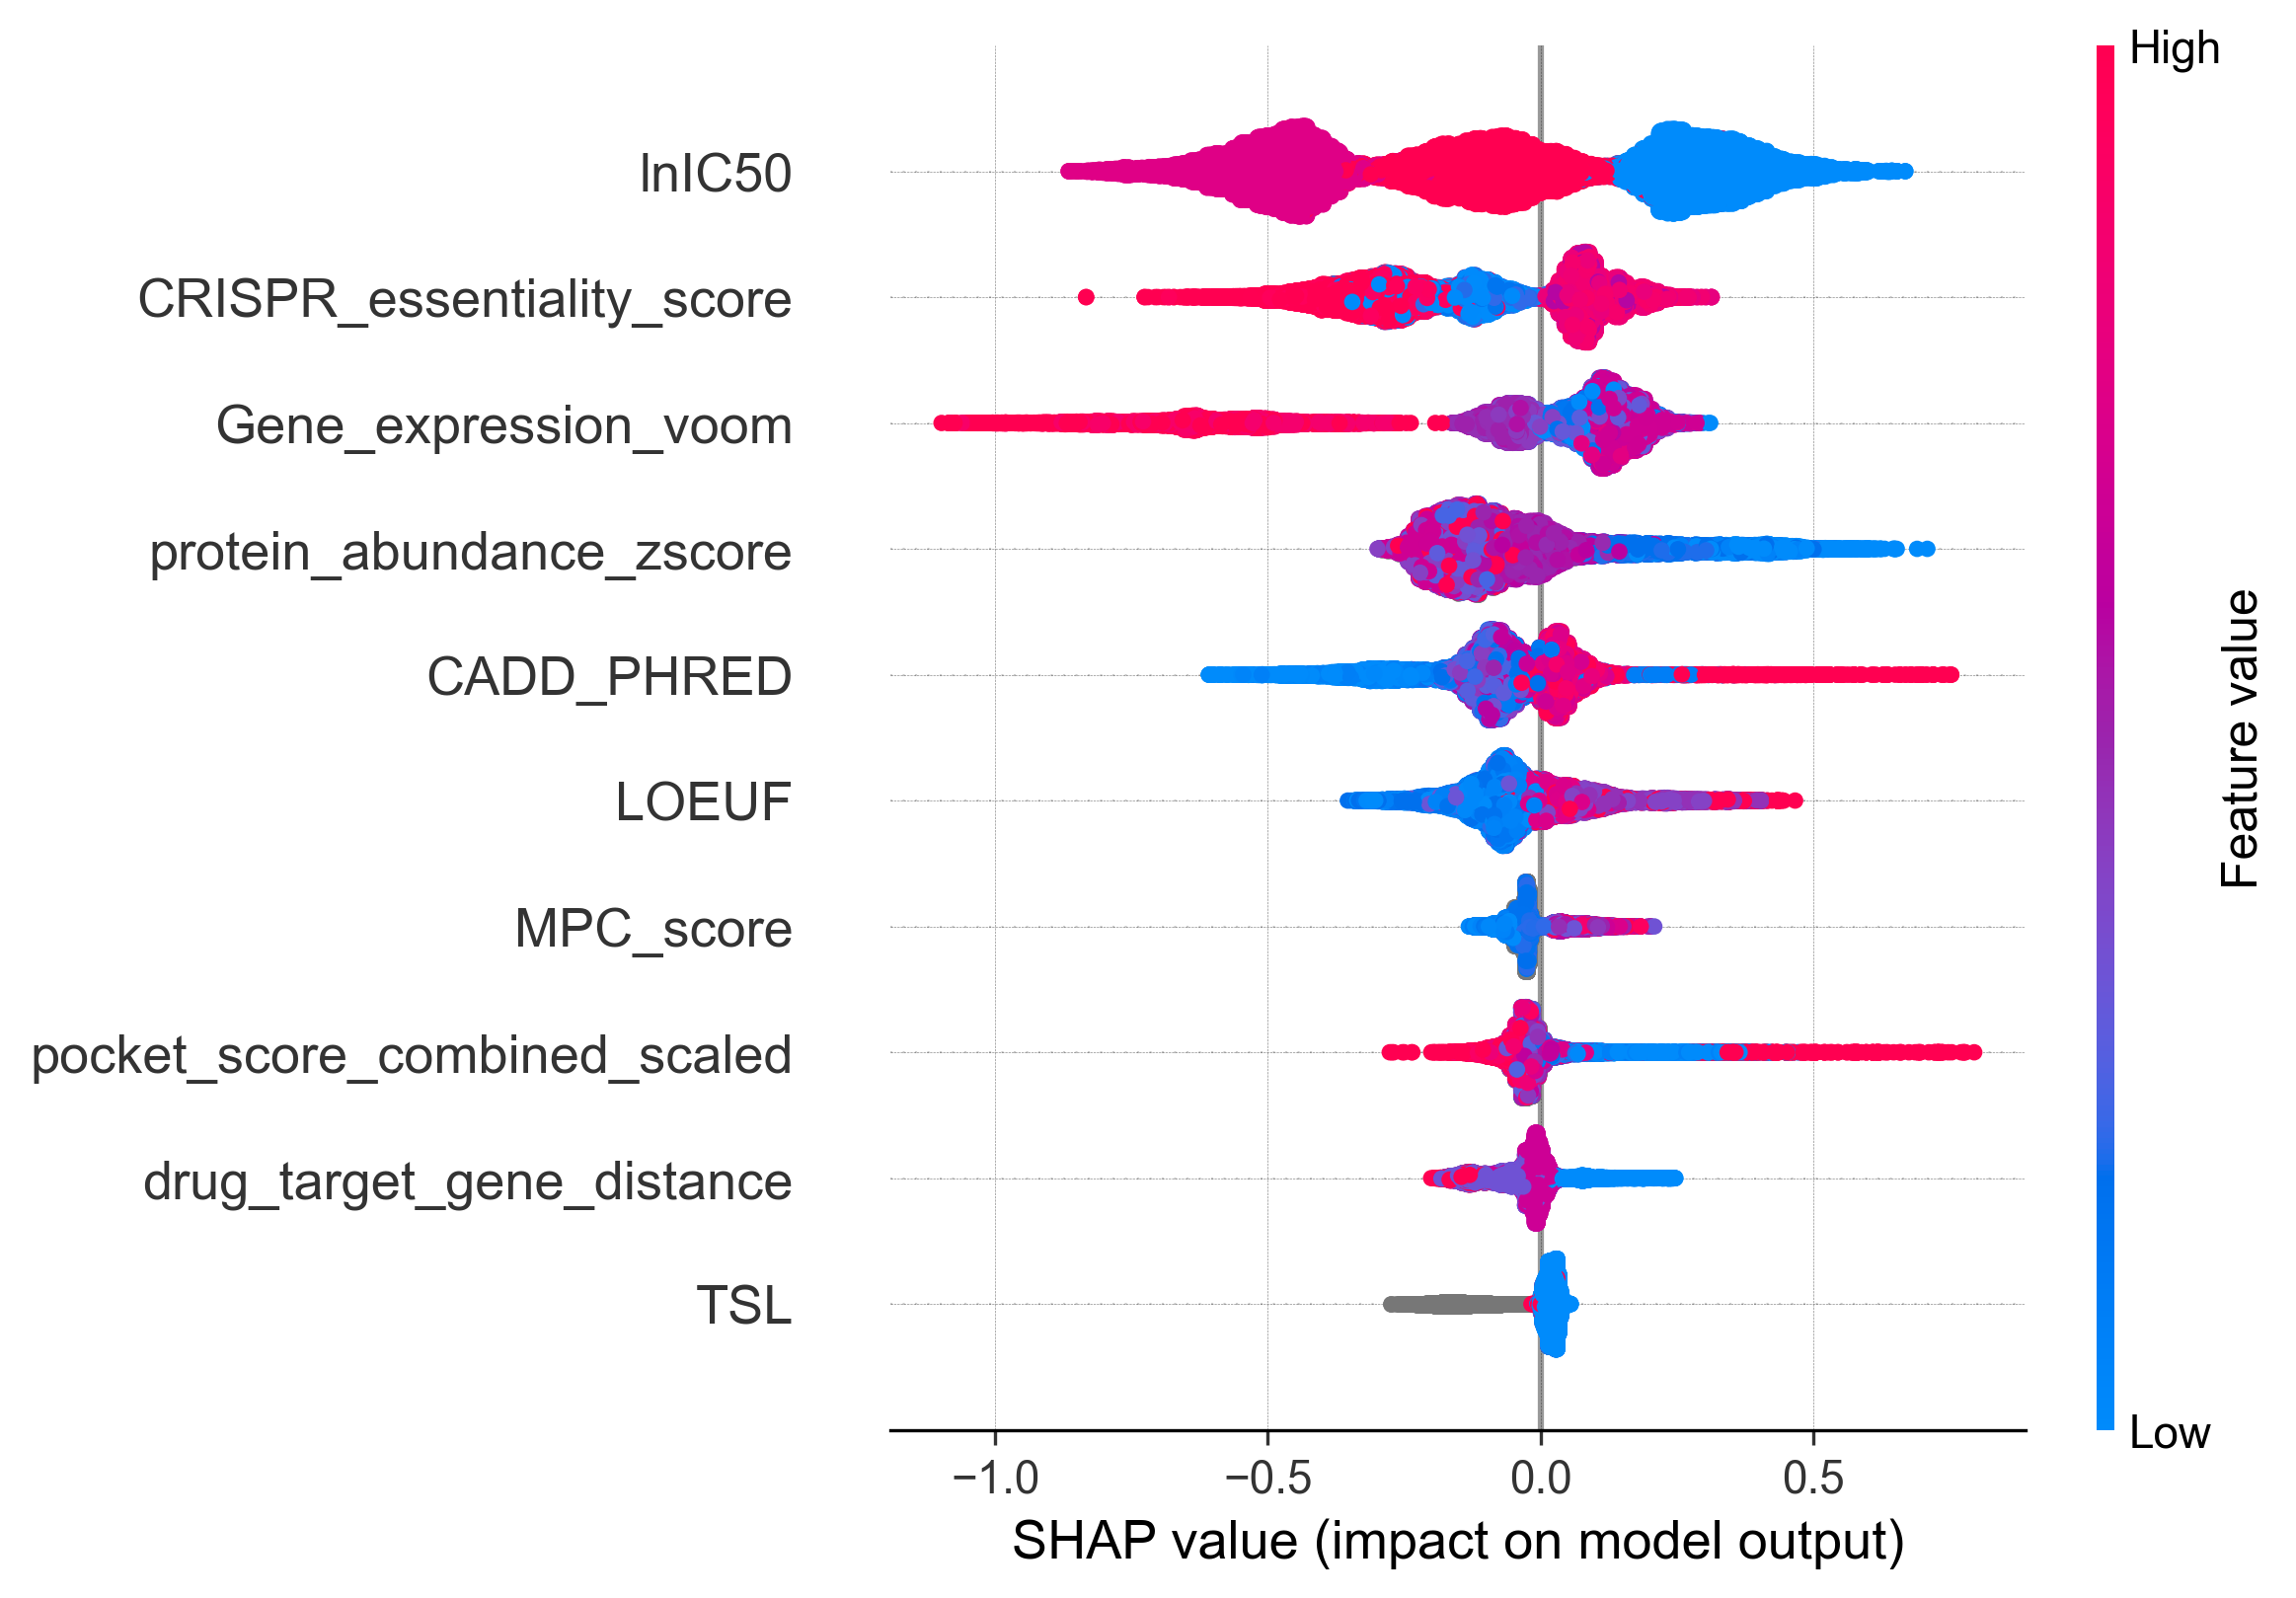

In [38]:
plot_topk_shap_for_class(shap_values, X_test, le, target_class='Sensitivity', k=10)


=== Neutral: Top 10 by mean(|SHAP|) ===
CADD_PHRED                   0.224522
lnIC50                       0.166483
CRISPR_essentiality_score    0.118453
MVP_score                    0.066995
bStatistic                   0.049995
drug_target_gene_distance    0.044223
MetaRNN_score                0.040682
mutfunc_exp                  0.039608
BayesDel_noAF_score          0.036462
GERP++_NR                    0.034202
dtype: float32


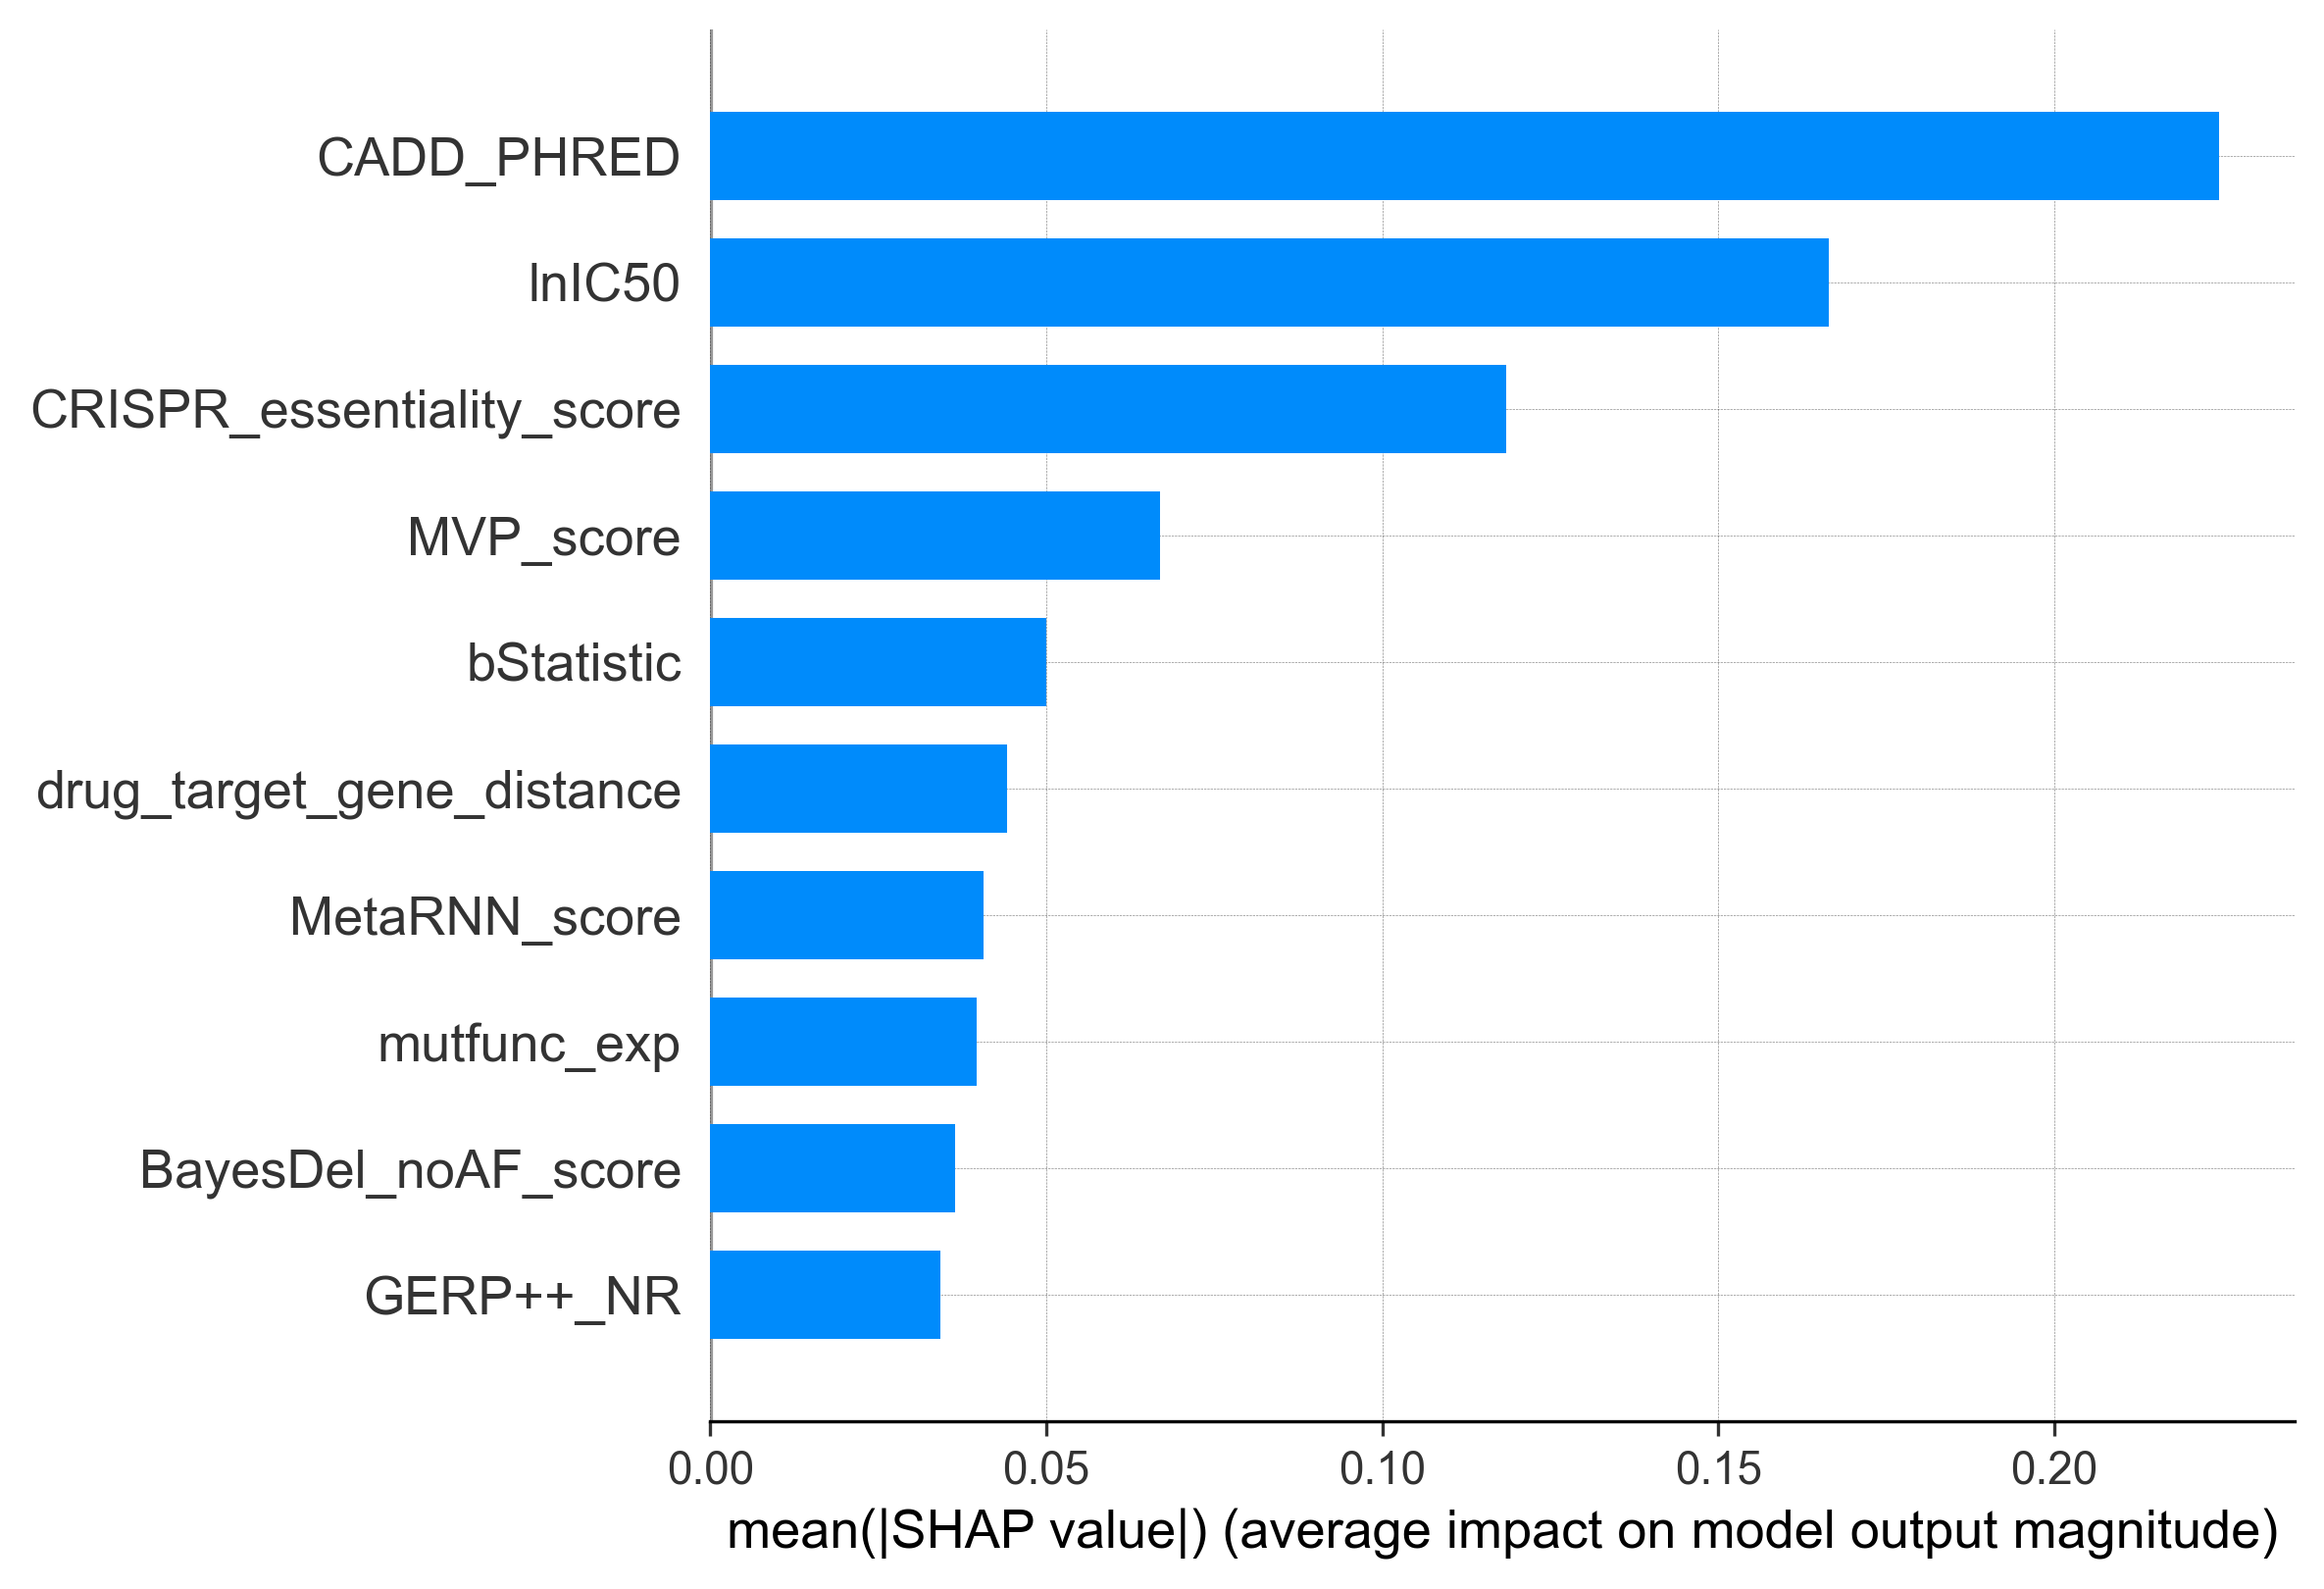

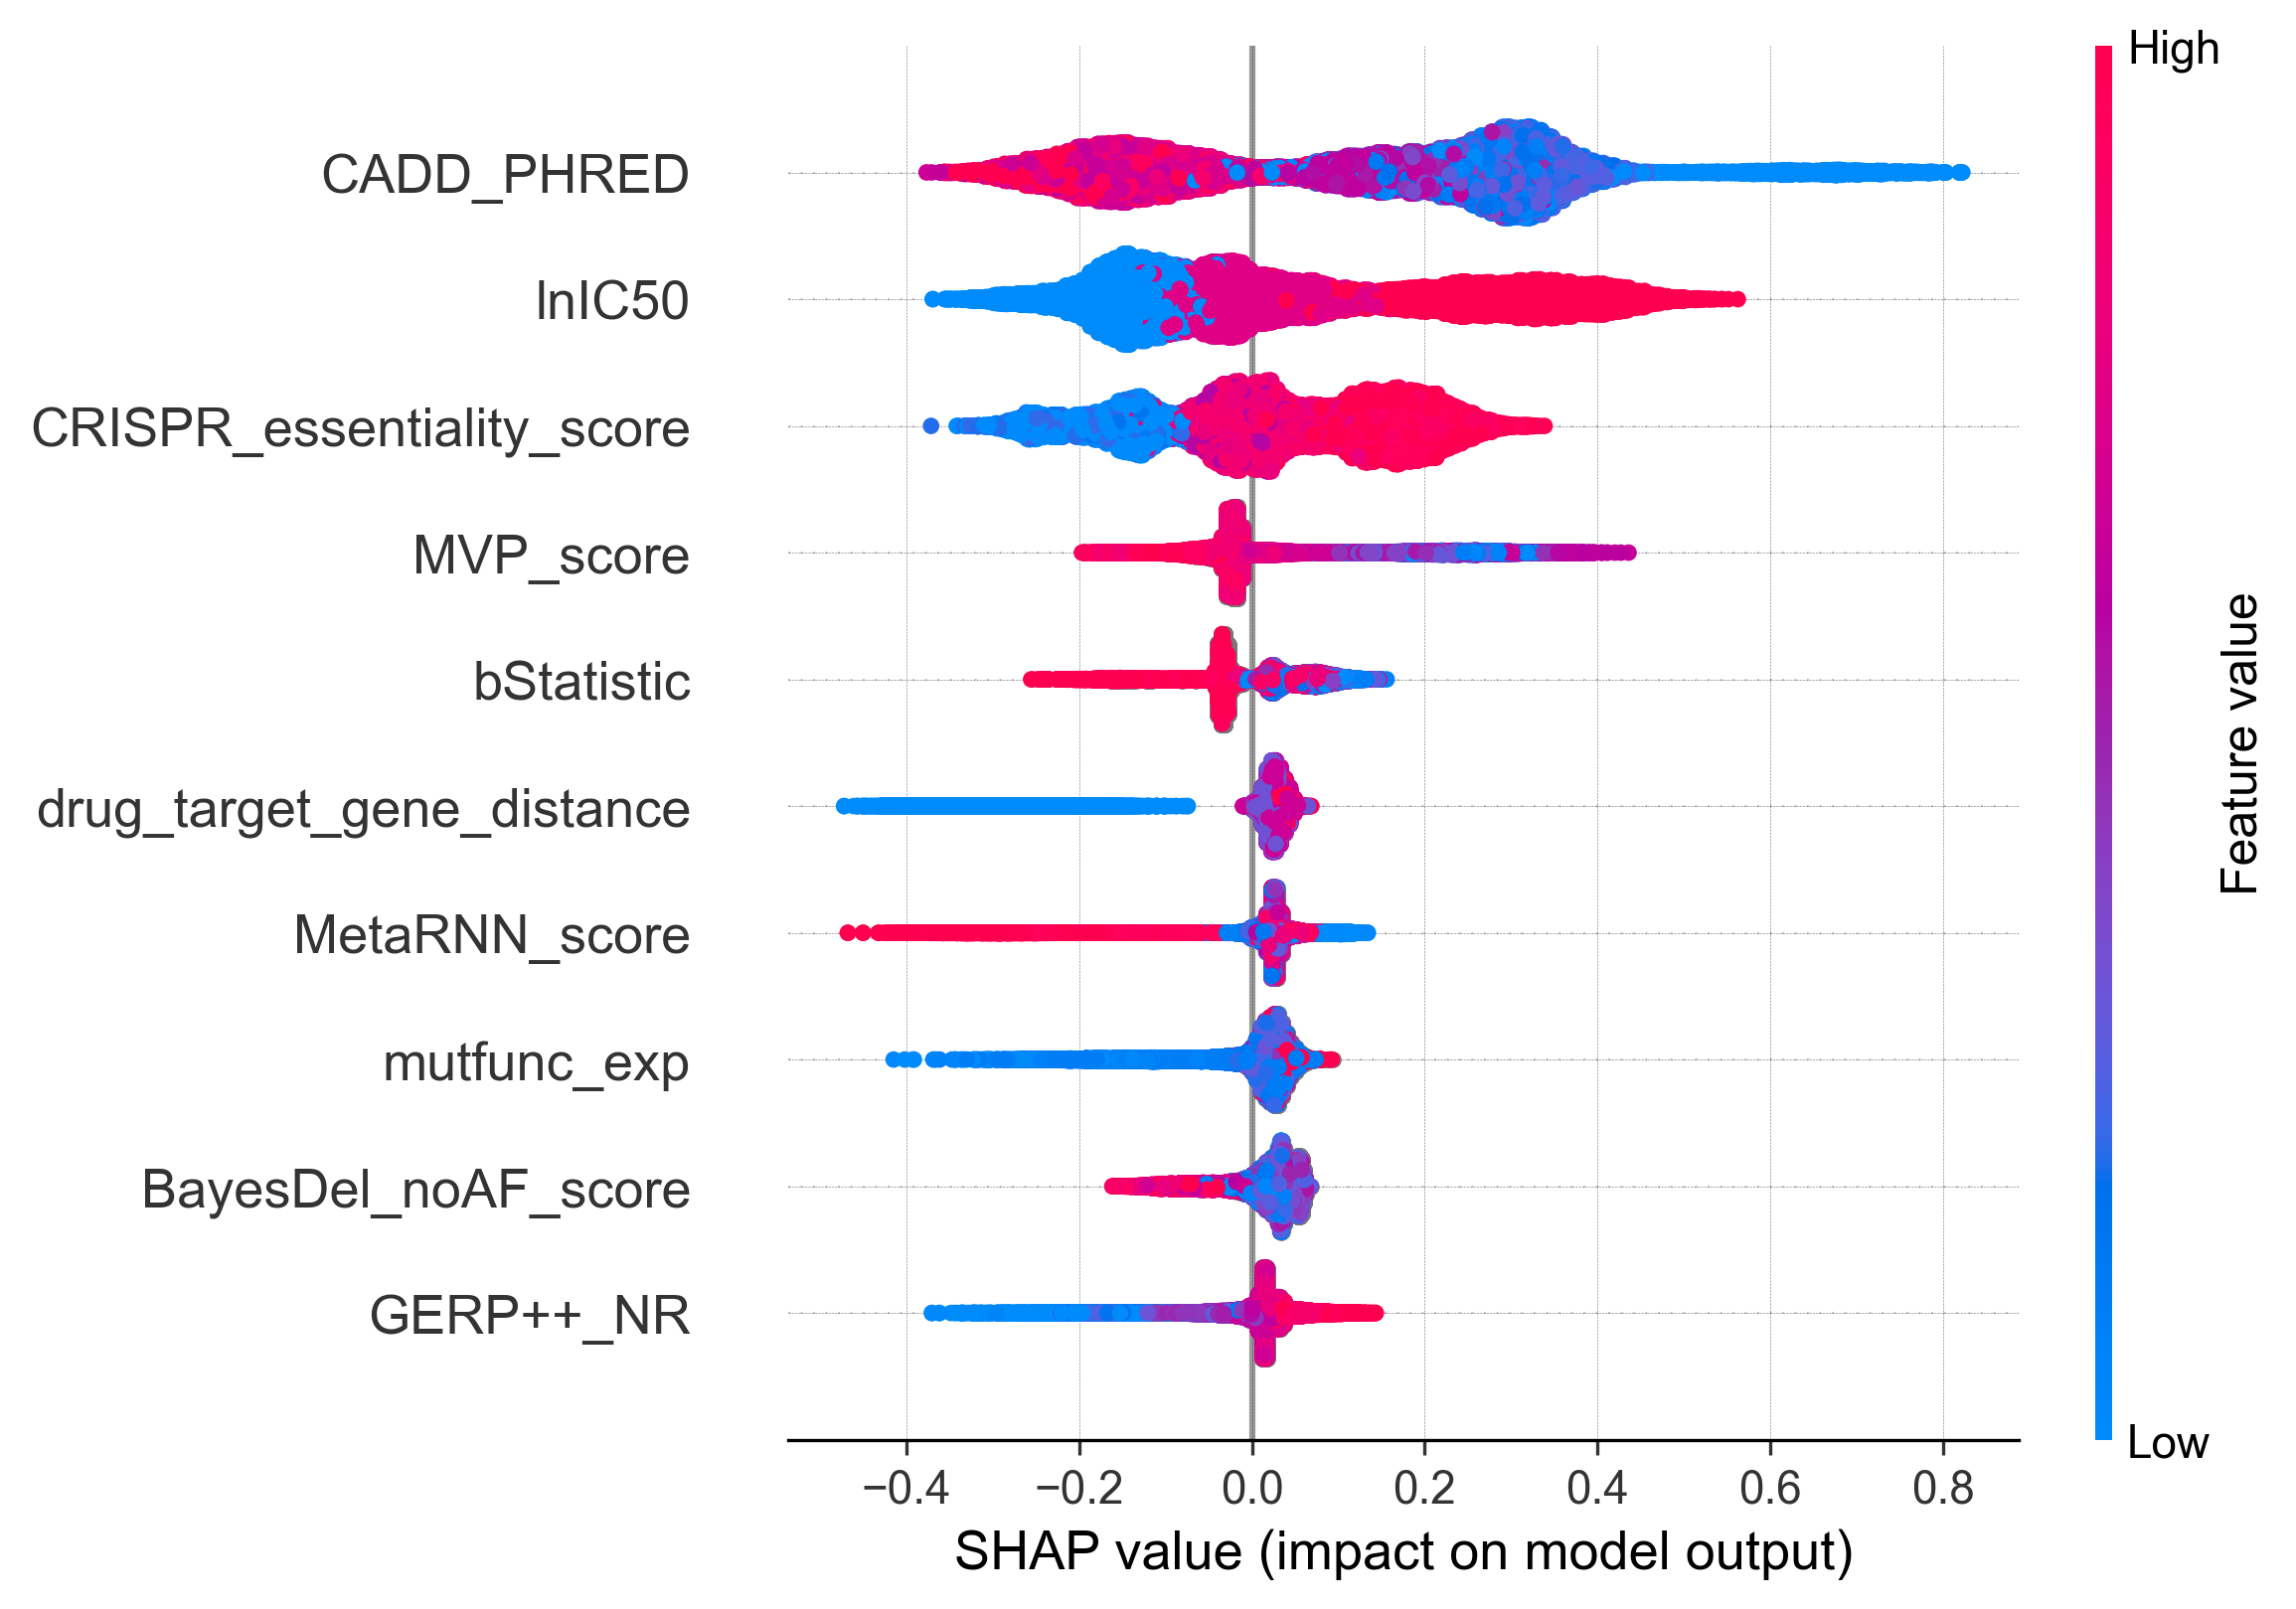

In [39]:
plot_topk_shap_for_class(shap_values, X_test, le, target_class='Neutral', k=10)


=== Resistance: Top 10 by mean(|SHAP|) ===
lnIC50                          0.240690
CRISPR_essentiality_score       0.215697
protein_abundance_zscore        0.071770
CADD_PHRED                      0.066695
DANN_score                      0.061739
TSL                             0.059447
LOEUF                           0.057570
pocket_score_combined_scaled    0.053009
Gene_expression_voom            0.047059
SpliceAI_pred_DP_DL             0.041930
dtype: float32


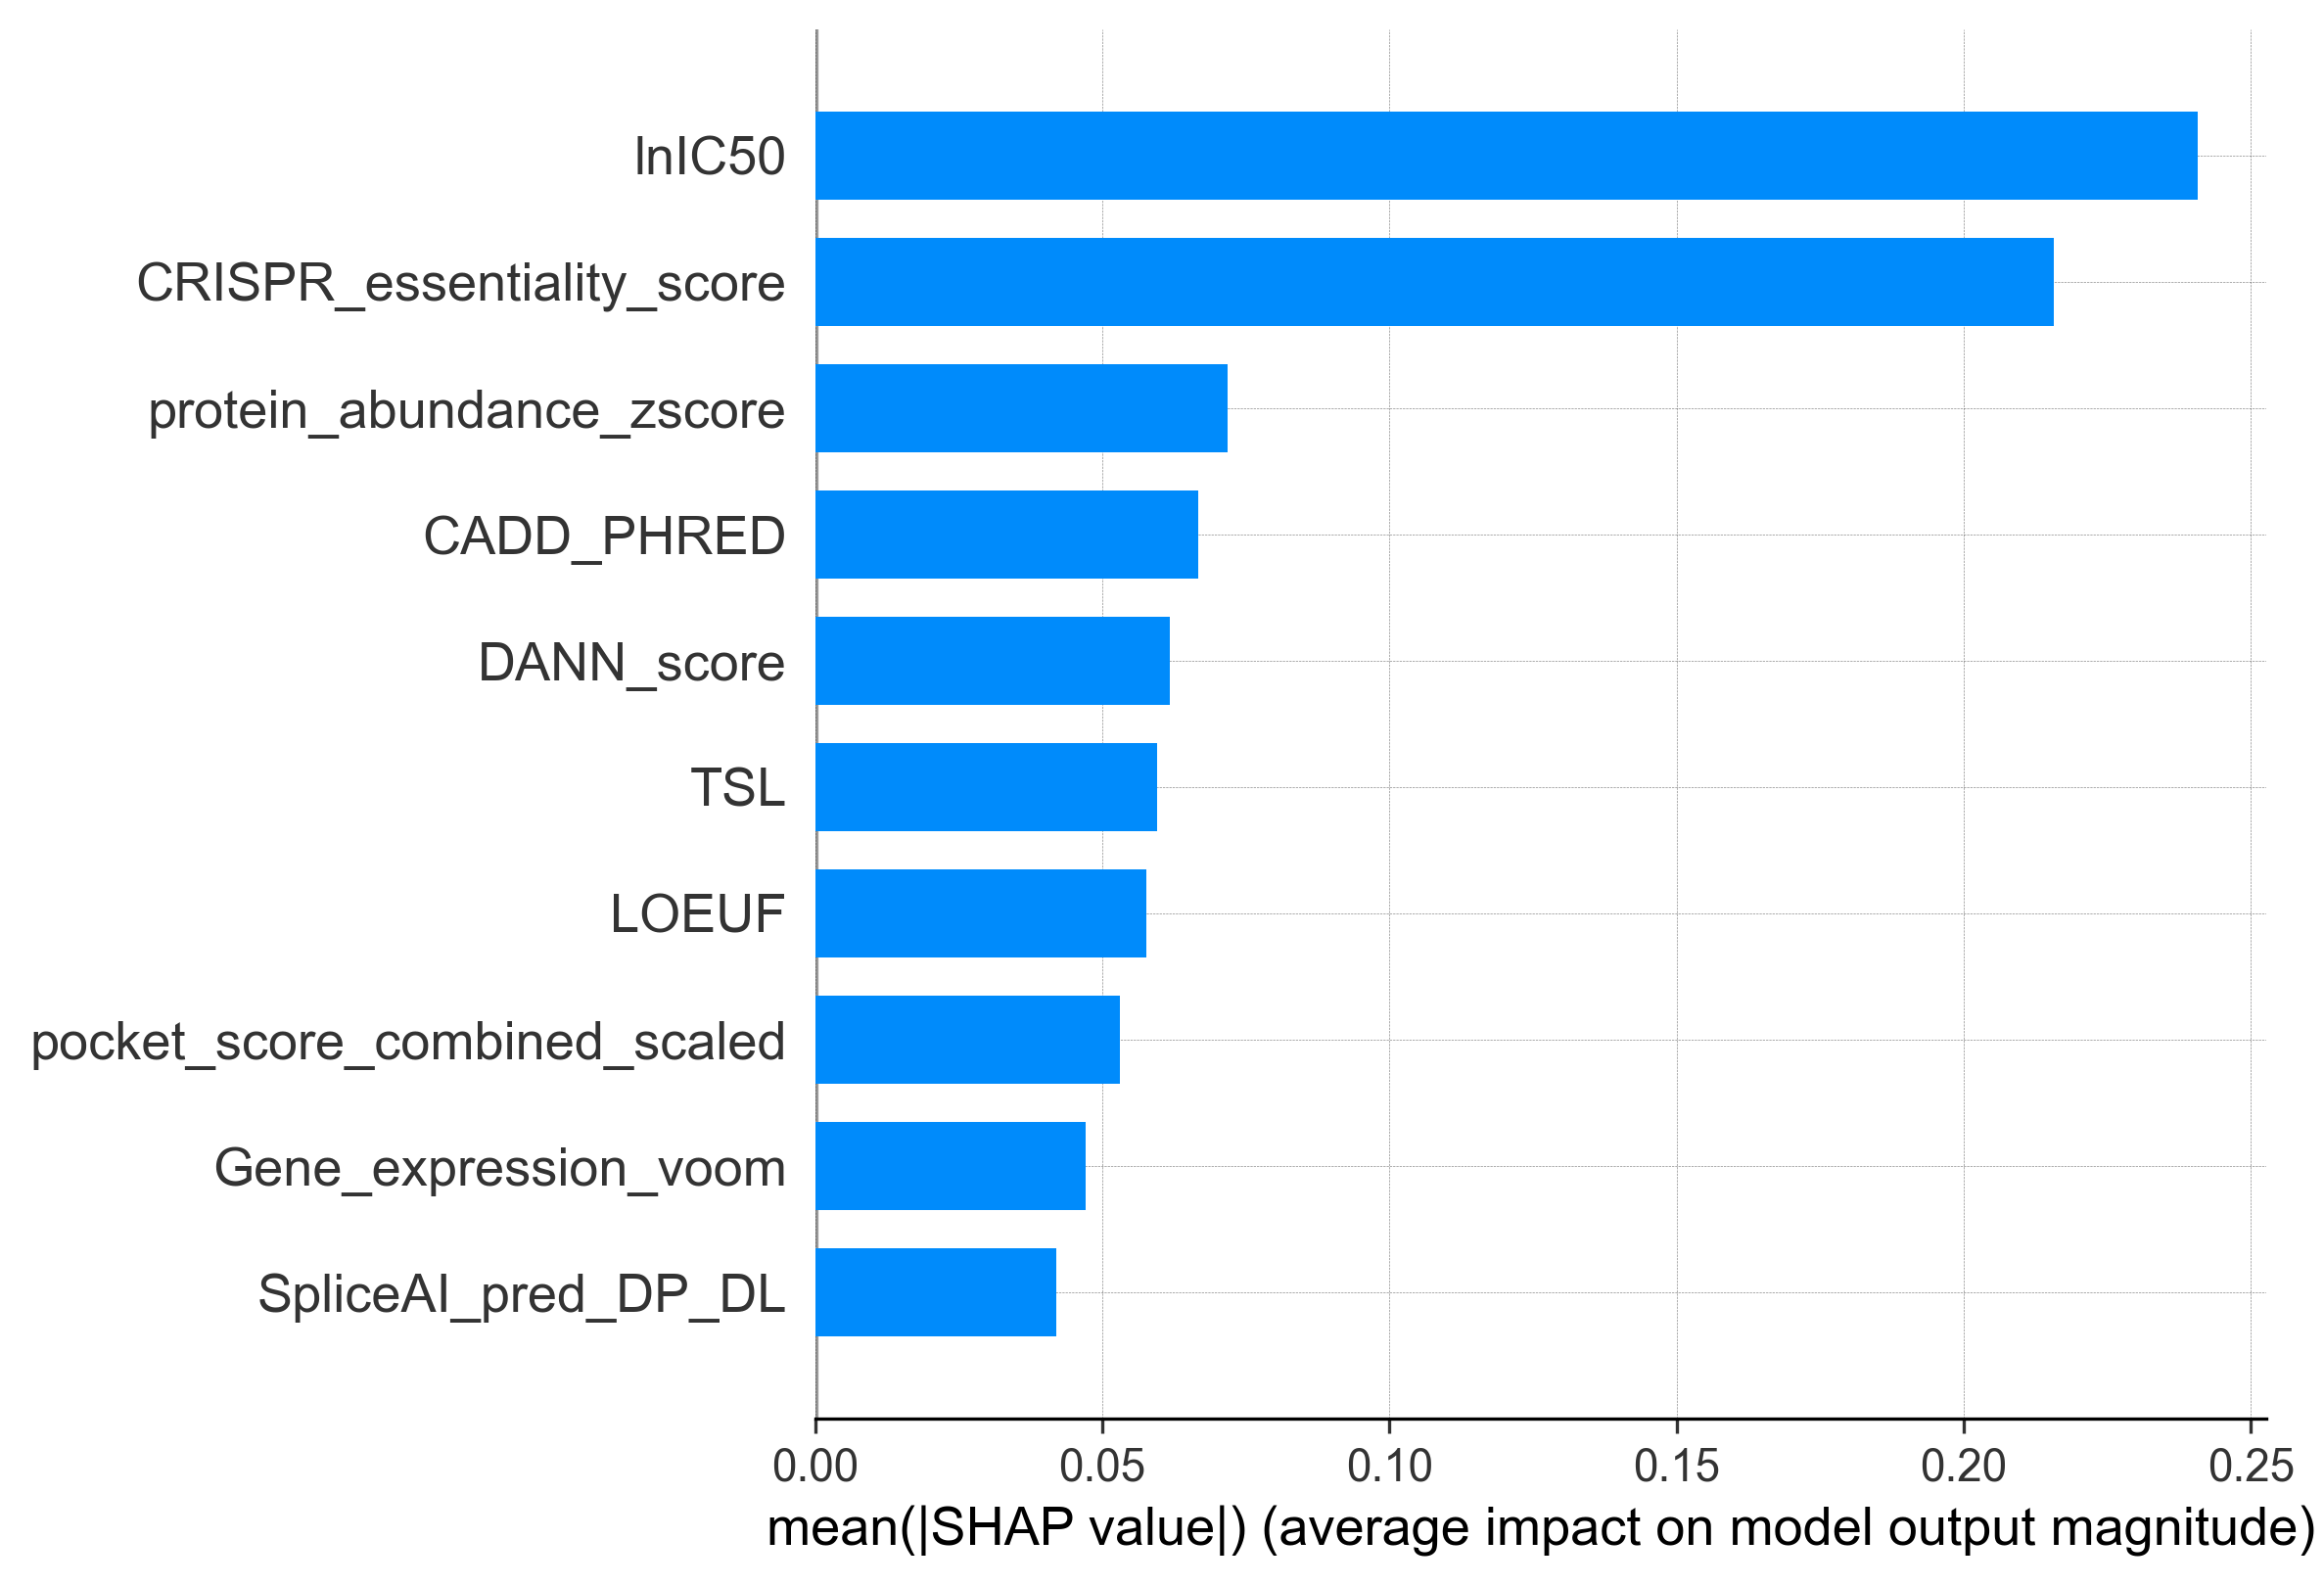

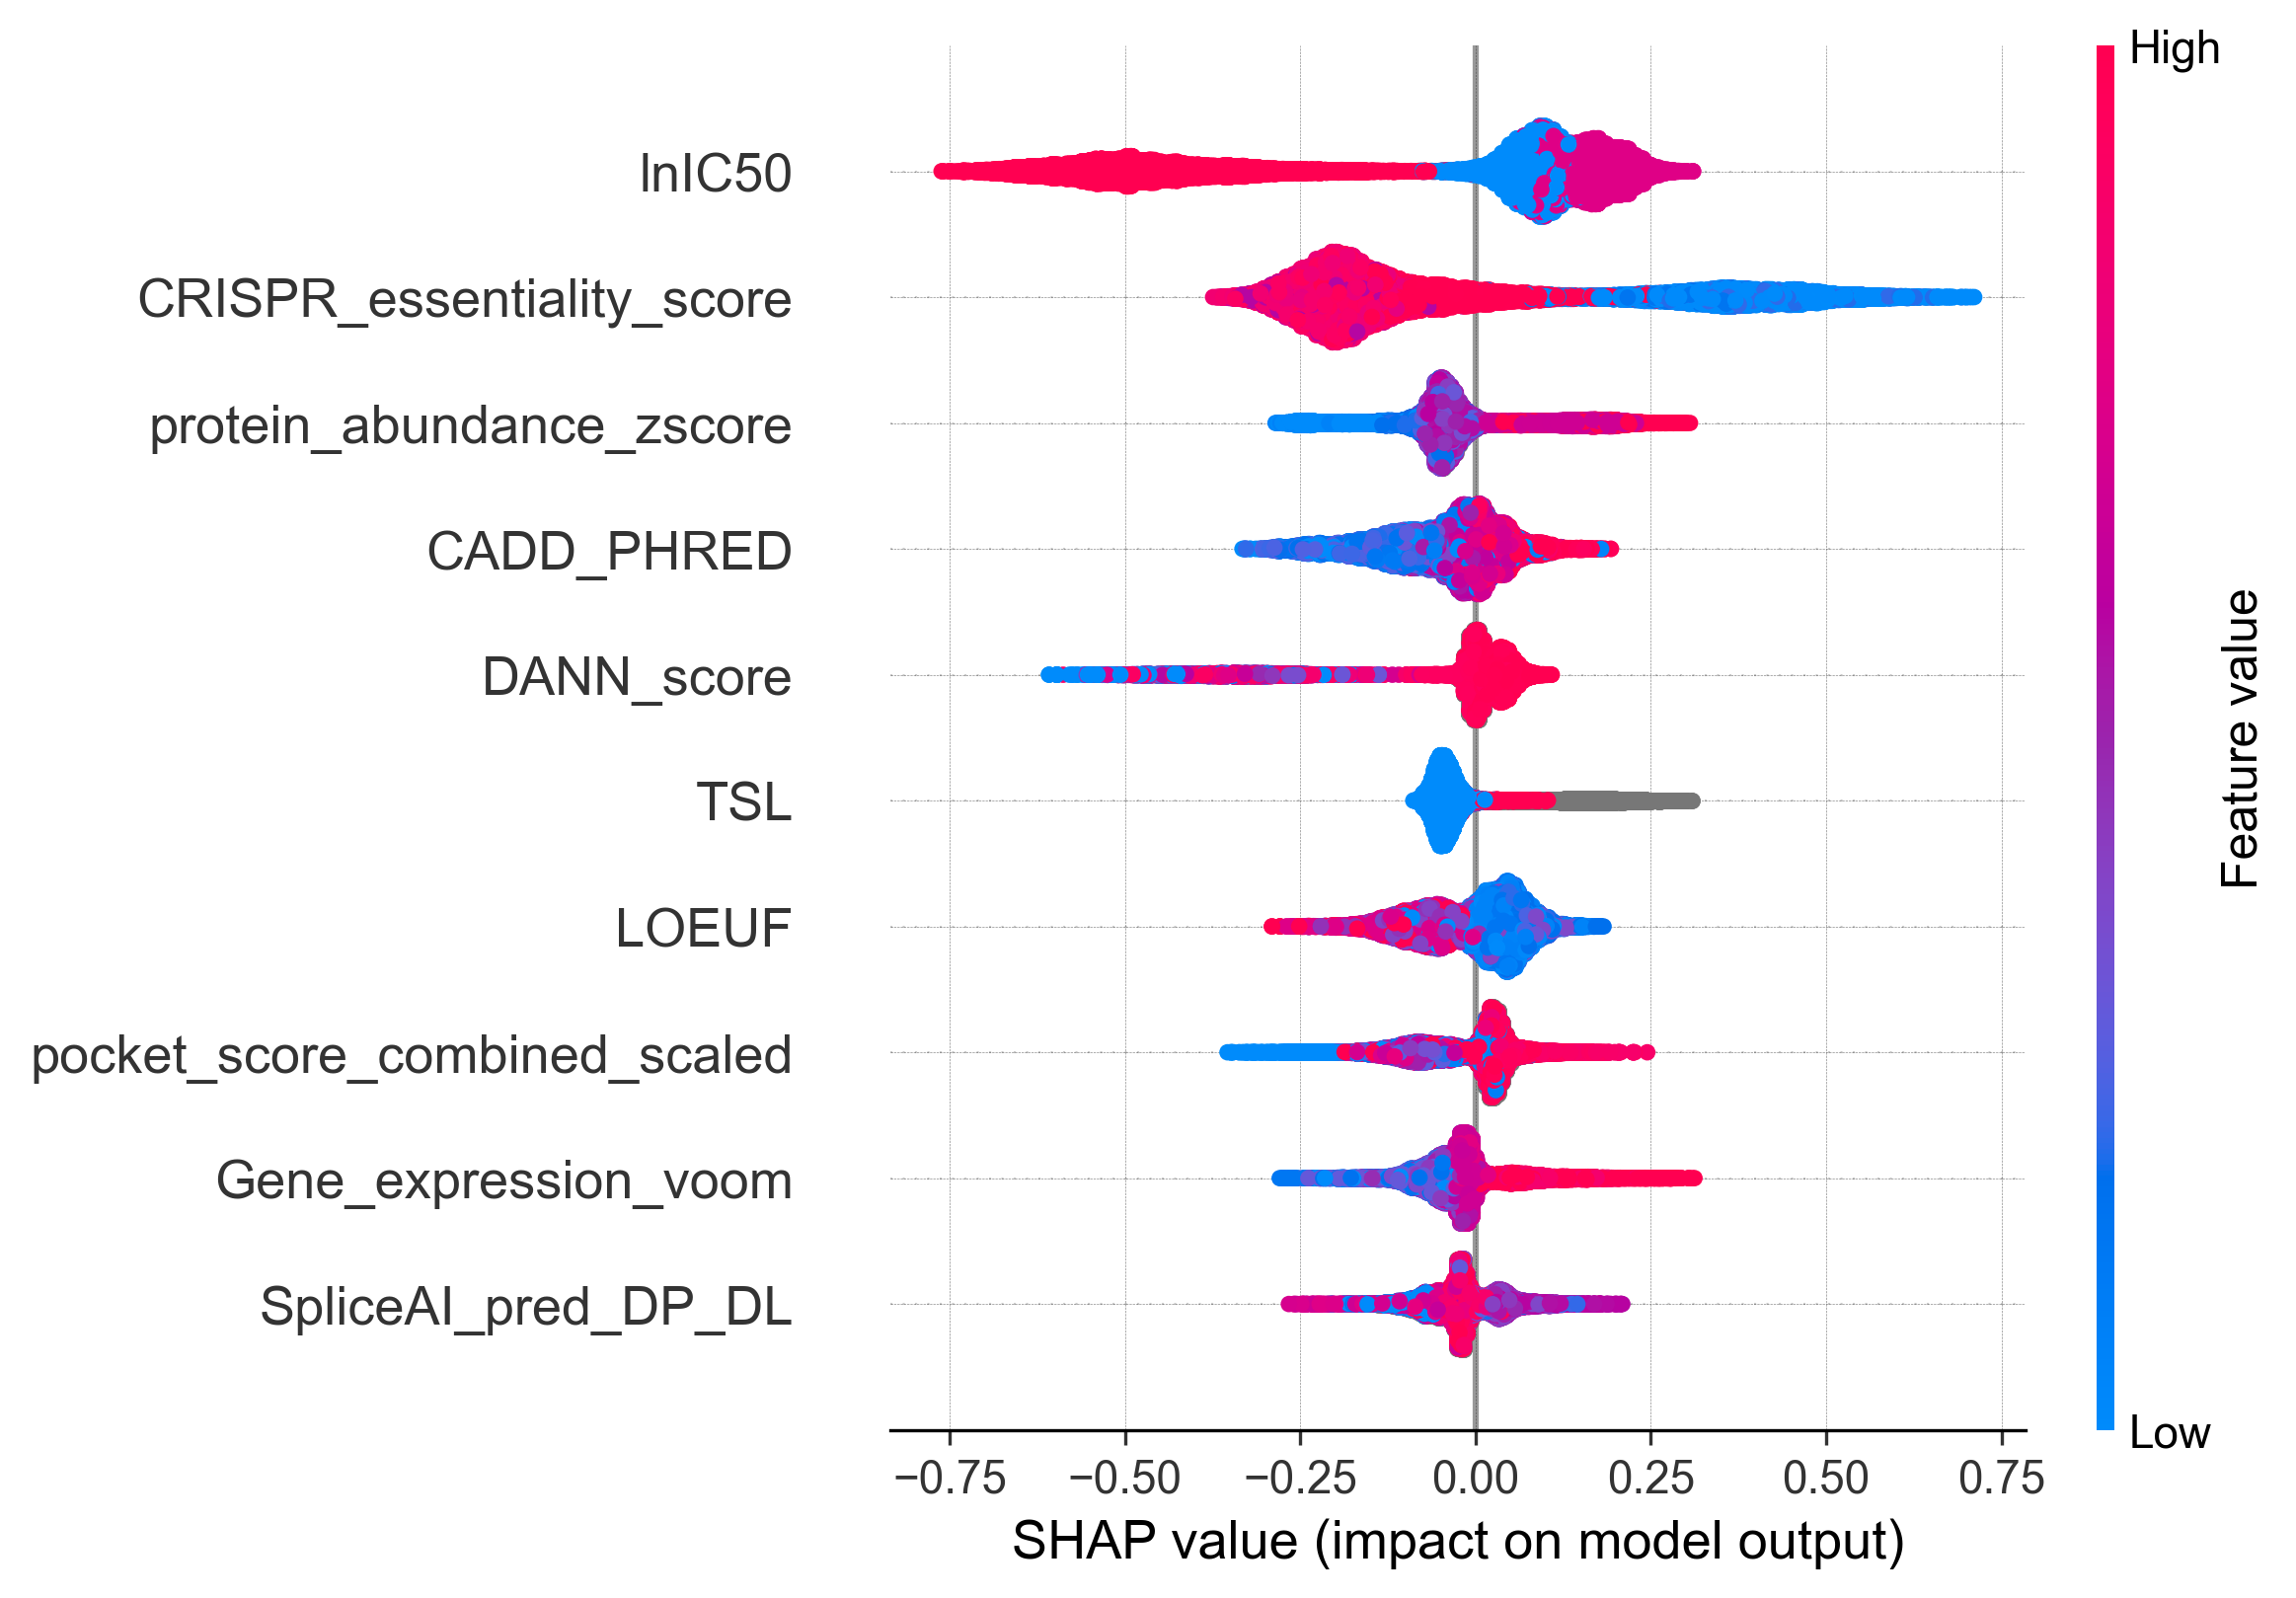

In [40]:
plot_topk_shap_for_class(shap_values, X_test, le, target_class='Resistance', k=10)

### SHAP UMAP

In [41]:
def get_shap_predicted_class(shap_values, y_pred):
    """
    Get SHAP values corresponding to the predicted class for each sample.
    """
    assert shap_values.shape[0] == len(y_pred)
    return shap_values[np.arange(len(y_pred)), :, y_pred]

def get_shap_umap_embedding(shap_matrix, n_neighbors=15, min_dist=0.1, random_state=42, scale=True):
    """
    Run UMAP on SHAP vectors.
    shap_values: (n_samples, n_features)
    """
    X_embed = shap_matrix.copy()

    if scale:
        #SHAP values can have different ranges across features
        X_embed= StandardScaler().fit_transform(X_embed)
    
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=2, random_state=random_state)

    embedding = reducer.fit_transform(X_embed)
    return embedding

def plot_umap(embedding, color=None, cmap="viridis"):
    plt.figure(figsize=(6, 5))
    plt.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=color,
        cmap=cmap,
        s=6,
        alpha=0.7
    )
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.tight_layout()
    plt.show()

#### UMAP for SHAP values corresponding to predicted classes

In [42]:
#SHAP of the predicted class for each sample
shap_pred= get_shap_predicted_class(shap_values, y_pred)

#SHAP per class
idx_sensitivity = list(le.classes_).index("Sensitivity")
idx_neutral = list(le.classes_).index("Neutral")
idx_resistance = list(le.classes_).index("Resistance")

shap_sensitivity = shap_values[:, :, idx_sensitivity]
shap_neutral = shap_values[:, :, idx_neutral]
shap_resistance = shap_values[:, :, idx_resistance]

In [43]:
shap_sensitivity.shape, shap_neutral.shape, shap_resistance.shape, shap_pred.shape

((42012, 68), (42012, 68), (42012, 68), (42012, 68))

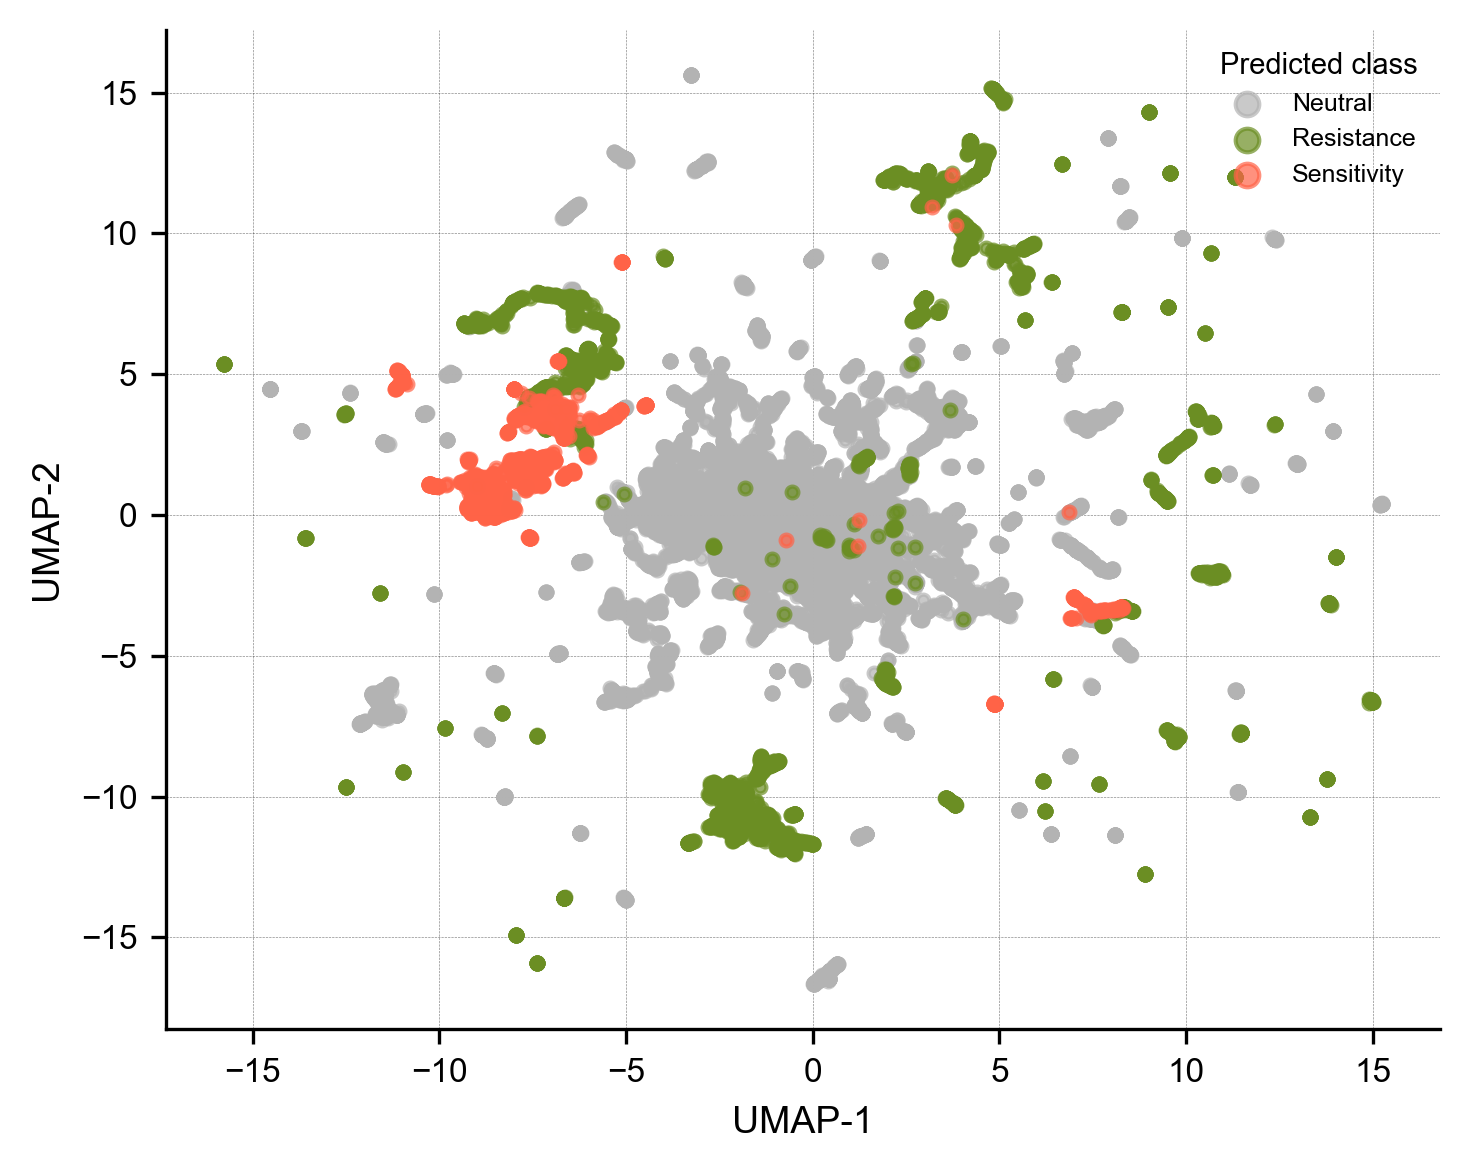

In [172]:
# UMAP colored by predicted class
class_labels = {i: c for i, c in enumerate(le.classes_)}
class_colors = {
    0: "#b3b3b3",
    1: "olivedrab",
    2: "tomato",
}

plt.figure(figsize=(5, 4))

for class_idx in np.unique(pred_labels):
    mask = pred_labels == class_idx

    plt.scatter(
        embed_pred[mask, 0],
        embed_pred[mask, 1],
        c=class_colors[class_idx],
        label=class_labels[class_idx],
        s=8,
        alpha=0.7
    )

plt.xlabel("UMAP-1", fontsize=9)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.ylabel("UMAP-2", fontsize=9)
plt.legend(title="Predicted class", markerscale=2, fontsize=6, title_fontsize=7, loc="upper right")
plt.tight_layout()
plt.show()

# EDA

In [101]:
annotated_variants_df.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Source,Target Transcript ID,uniprot_accession,RefSeq match transcript (MANE Select),Amino Acid Edits,aa_change,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,EVE_SCORE,AlphaMissense_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_voom,foldx_ddg,alphafold_plddt,pocket_id,min_pocket_buriedness,pocket_plddt_mean,pocket_score_combined_scaled,CRISPR_essentiality_score,is_in_interface,interface_count,protein_abundance_zscore,gene_cn_total,gene_cn_category_enc,gene_cn_category_Amplification,gene_cn_category_Gain,gene_cn_category_Loss,gene_cn_category_Neutral,lnIC50,drug_target_gene_distance,is_drug_target,Class,Class_encoded
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,PIC,0.274277,NaN,ENST00000357387.8,Q6R327,NM_152756.5,His1109Tyr,H1109Y,3.0,2.0,1.0,1.0,0.000,0.214,0.463040,NaN,0.0685,-0.402171,0.970933,0.045001,-4.388,5.314964,0.516773,5.75,5.75,0.917608,0.44121,0.445060,0.093490,0.179100,-1.0259,0.000785,0.345,-0.22,1.0,0.094767,226.0,0.800526,NaN,1.000,5.938,20.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.305,NaN,NaN,5.531900,NaN,NaN,NaN,NaN,NaN,NaN,-0.243777,0.0,0.0,0.36936,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,2.0,0.0,Neutral,0
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,PIC,0.399691,NaN,ENST00000369535.5,P01111,NM_002524.5,Leu171Phe,L171F,3.0,2.0,1.0,0.1,NaN,0.141,0.413488,NaN,0.1149,-0.222424,0.993713,0.120039,-5.943,3.683551,0.294249,5.86,5.86,0.865513,0.74516,1.008632,0.619943,0.190982,-0.9613,0.907693,1.385,-1.28,1.0,0.072730,819.0,0.580949,0.628916,1.000,4.055,23.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.550,NaN,NaN,6.702081,-0.239753,88.23,NaN,NaN,NaN,NaN,-0.178272,0.0,0.0,-0.61887,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,1.0,0.0,Neutral,0
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,PIC,0.399178,NaN,ENST00000674063.1,P42338,NM_006219.3,Thr930Ile,T930I,3.0,2.0,NaN,0.0,0.862,NaN,0.373381,NaN,NaN,-0.058094,0.998396,0.879846,-10.191,4.891242,0.469329,5.63,3.78,NaN,0.73854,NaN,NaN,NaN,0.6434,0.529280,3.705,NaN,0.0,0.365695,856.0,0.310513,NaN,0.998,2.094,25.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.319,NaN,NaN,5.786491,-0.070749,91.70,10.0,0.848224,90.132188,949.413840,-0.290119,0.0,0.0,0.05922,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,0.0,1.0,Neutral,0
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,PIC,-0.801011,NaN,ENST00000275493.7,P00533,NM_005228.5,Leu480Leu,L480L,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.0,0.0,0.0,0.0,NaN,0.475,-0.01879,NaN,3.875409,NaN,NaN,6.0,0.808046,94.882812,975.087068,-0.075387,0.0,0.0,-0.74347,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,1.0,0.0,Neutral,0
4,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,PIC,-0.379377,NaN,ENST00000621592.8,P01106,NM_002467.6,Asp2Asn,D2N,3.0,2.0,1.0,0.0,0.199,NaN,0.453567,NaN,0.1399,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,4.31,2.43,0.397160,NaN,NaN,0.733174,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,951.0,0.226082,0.128201,1.000,1.507,22.100,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.0,0.0,0.0,0.0,1.0,0.128,NaN,NaN,3.687539,-0.237760,55.70,NaN,NaN,NaN,NaN,-1.698486,0.0,0.0,NaN,3.0,2.0,0.0,0.0,0.0,1.0,0.311144,2.0,0.0,Neutral,0


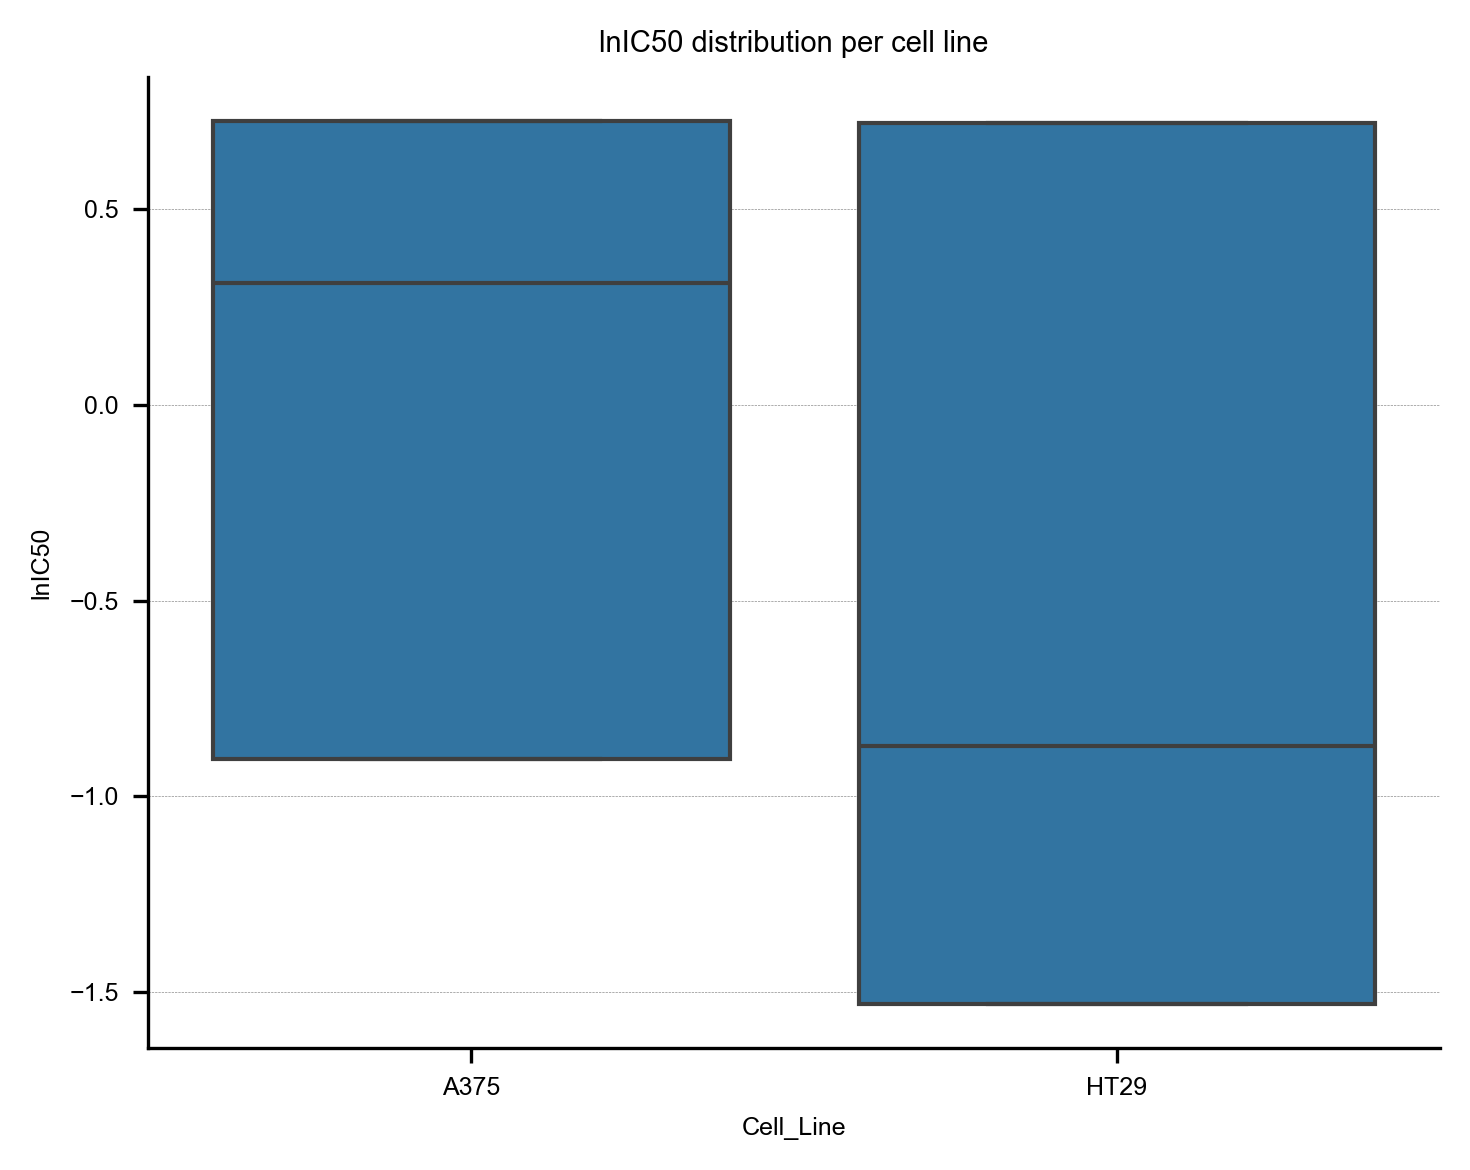

In [109]:
feature = "lnIC50"

plt.figure(figsize=(5,4))
sns.boxplot(
    data=annotated_variants_df,
    x="Cell_Line",
    y=feature
)
plt.title(f"{feature} distribution per cell line")
plt.tight_layout()
plt.show()

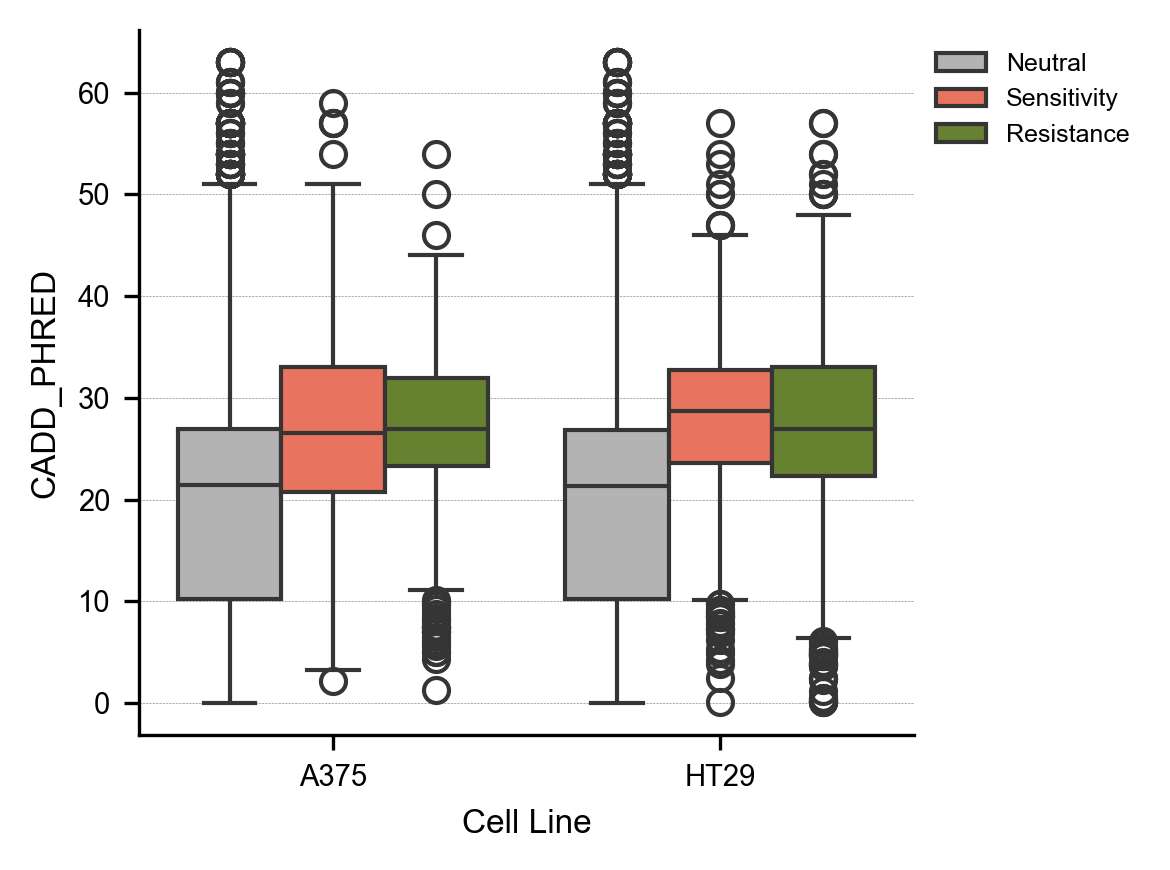

In [116]:
feature = 'CADD_PHRED'
palette = {
    "Neutral": "#b3b3b3",
    "Resistance": "olivedrab",
    "Sensitivity": "tomato"
}

plt.figure(figsize=(4,3))
sns.boxplot(
    data=annotated_variants_df,
    x="Cell_Line",
    y=feature,
    hue="Class",
    palette=palette
)
#plt.title(f"{feature} per cell line and class")
plt.xlabel("Cell Line", fontsize=8)
plt.xticks(fontsize=7)
plt.ylabel(feature, fontsize=8)
plt.yticks(fontsize=7)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [118]:
annotated_control_df['Drug'].unique()

array(['PIC', 'SCH', 'LIN', 'ADAG', 'SOTOR', 'DEB-CET', 'TRAM', 'GEFIT',
       'OSIM', 'NIRAP', 'OLAP'], dtype=object)

In [122]:
drugs_check = pd.read_csv('data/4_Screen_zscores/Merge_Control.csv')

In [120]:
drugs_check['Drug'].unique()

array(['PIC', 'SCH', 'LIN', 'ADAG', 'SOTOR', 'DEB-CET', 'TRAM', 'GEFIT',
       'OSIM', 'NIRAP', 'OLAP'], dtype=object)

In [123]:
drugs_check.head()

,Guide,Gene,Editor,A375_PIC_Control,A375_SCH_Control,A375_LIN_Control,HT29_PIC_Control_EG,HT29_SCH_Control,HT29_LIN_Control,H23_ADAG_Control,H23_SOTOR_Control,HT29_DEB-CET_Control,HT29_PIC_Control_MC,HT29_TRAM_Control,PC9_GEFIT_Control,PC9_OSIM_Control,MHHES1_NIRAP_Control,MHHES1_OLAP_Control
0,AAAAAAAAAAACTAAGAGTT,KRAS,ABE,NaN,NaN,NaN,NaN,NaN,NaN,0.349536,0.281788,-0.092111,-0.440937,0.237055,-0.323425,-0.429644,0.742707,0.546180
1,AAAAAAAAAAACTAAGAGTT,KRAS,CBE,NaN,NaN,NaN,NaN,NaN,NaN,0.801893,-0.404665,1.183724,0.174917,0.862387,0.509532,-0.063357,NaN,NaN
2,AAAAAAAAAAGTAAGCTTCA,KRAS,ABE,NaN,NaN,NaN,NaN,NaN,NaN,0.346023,0.635084,0.050661,0.711641,0.578670,-0.279569,-0.361358,-0.079732,0.226823
3,AAAAAAAAAAGTAAGCTTCA,KRAS,CBE,NaN,NaN,NaN,NaN,NaN,NaN,-0.339015,0.169475,-0.652642,-0.273429,-0.103004,-0.428180,0.882738,NaN,NaN
4,AAAAAAAAAATCAATGGTGG,BCL2,ABE,NaN,NaN,NaN,NaN,NaN,NaN,-0.042433,1.692755,0.481643,1.075654,0.700159,-0.779421,-0.548121,-0.228105,-0.752463
